### Histogram Aggregator

Geometric Regularization from Overparameterized Learning Explains Double Descent and other findings

This noteboook is template for what will be provided with supplemental material

In [1]:
!pip install Automunge

In [2]:
#automunge import

from Automunge import *
am = AutoMunge()

In [3]:
#other imports

import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

import matplotlib.pyplot as plt
# import numpy as np
from matplotlib import colors
from matplotlib.ticker import PercentFormatter

import timeit
import pickle


In [4]:
#load titanic data set
ds = tfds.load('titanic', split='train', shuffle_files=False, with_info=True)
df_train = tfds.as_dataframe(ds[0], ds[1])
columns = list(df_train)
#this converts column headers to remove a prefix
columns.remove('survived')
columns = [x[9:] for x in columns]
columns += ['survived']
df_train.columns = columns

labels_column = 'survived'

df_train.head()

,age,boat,body,cabin,embarked,fare,home.dest,name,parch,pclass,sex,sibsp,ticket,survived
0,30.0,b'Unknown',-1,b'Unknown',2,13.0000,"b'Sarnia, ON'","b'McCrie, Mr. James Matthew'",0,1,0,0,b'233478',0
1,37.0,b'Unknown',98,b'Unknown',2,7.9250,"b'Ruotsinphytaa, Finland New York, NY'","b'Gustafsson, Mr. Anders Vilhelm'",0,2,0,2,b'3101276',0
2,28.0,b'9',-1,b'Unknown',2,13.0000,b'Spain',"b'Reynaldo, Ms. Encarnacion'",0,1,1,0,b'230434',1
3,18.0,b'Unknown',-1,b'Unknown',2,73.5000,"b'Lyndhurst, England'","b'Davies, Mr. Charles Henry'",0,1,0,0,b'S.O.C. 14879',0
4,-1.0,b'Unknown',-1,b'Unknown',0,7.8958,b'Unknown',"b'Gheorgheff, Mr. Stanio'",0,2,0,0,b'349254',0


In [5]:
#this function initializes dense network model based on specified width, depth, initialization
#init_param1 / init_param2 are min/max for uniform initialization (RandomUniform)
#init_param3 is scale for normal (RandomNormal)
#returns one initalized model

def create_model(width, 
                 depth, 
                 init='uniform', 
                 init_param1=-0.5, 
                 init_param2=0.5,
                 init_param3=0.5):
  
  model = False
  
  #for init = 'uniform', param1 and param2 are min and max
  #for init = 'normal', param3 is scale and param1 and 2 ignored
  
  if init == 'uniform':
    initializer = tf.keras.initializers.RandomUniform(
      minval=init_param1, maxval=init_param2, seed=None
    )
  elif init == 'normal':
    initializer = tf.keras.initializers.RandomNormal(mean=0., stddev=init_param3)

  elif init == 'HeNormal':
    initializer = tf.keras.initializers.HeNormal(seed=None)

  elif init == 'HeUniform':
    initializer = tf.keras.initializers.HeNormal(seed=None)
  
  #create model with keras
  model = Sequential()

  for i in range(depth):
    model.add(Dense(width, activation='relu', kernel_initializer=initializer))

    # #batch norm inclusion scenario
    # model.add(Dense(width, activation=None, kernel_initializer=initializer))
    # model.add(BatchNormalization())
    # model.add(Activation("relu"))

    # #tanh smooth activation function scenario
    # #applying tanh to evaluate impact of a smooth activation function
    # model.add(Dense(width, activation='tanh', kernel_initializer=initializer))

  model.add(Dense(1, activation='sigmoid', kernel_initializer=initializer))

  #compile model
  model.compile(loss='binary_crossentropy', optimizer='adam', metrics=["accuracy"])
  
  return model

In [8]:
#this operation encodes the features

#let's try with just the three features
#these features were selected based on a feature importance evaluation
df_train = df_train[['pclass', 'sex', 'age', labels_column]]

#ordl is ordinal encoding, bnry is boolean integer, nmbr is z-score normalization
assigncat = {'ordl':'pclass', 
             'bnry':['sex', labels_column], 
             'nmbr':'age'}

train_am, train_ID, labels_am, \
val, val_ID, val_labels, \
test, test_ID, test_labels, \
postprocess_dict = \
am.automunge(df_train,
            labels_column = labels_column,
            assigncat = assigncat,
            MLinfill=False,
            NArw_marker=False,
            shuffletrain=False,
            pandasoutput = True,
            printstatus=False)

train_am.head()

,pclass_ordl,sex_bnry,age_nmbr
0,2,1,0.353931
1,3,1,0.745733
2,2,0,0.241988
3,2,1,-0.317729
4,3,1,-1.381190



experiment_number:  144
row_address:  (0, 1)
init:  HeNormal
width:  3
depth:  1



min =  9.417578439752106e-06
max =  10.358001708984375
median =  0.6931469440460205
mean =  0.9848128282623893
stdev =  1.05329311990136
mad =  0.6882391965227455



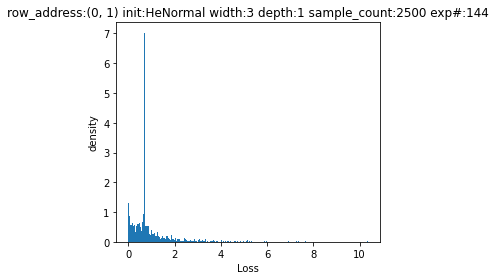


time elapsed:
412.707961652


experiment_number:  145
row_address:  (0, 1)
init:  HeNormal
width:  3
depth:  2

min =  -0.0
max =  13.063882827758789
median =  0.6931469440460205
mean =  0.9213622920234473
stdev =  1.0529028525092268
mad =  0.5711595323703004



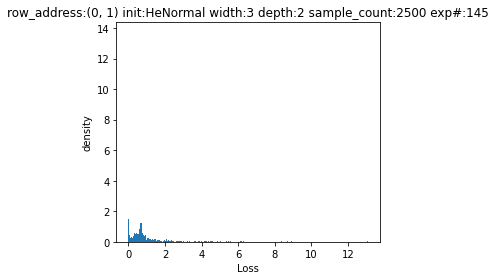


time elapsed:
364.87973427500003


experiment_number:  146
row_address:  (0, 1)
init:  HeNormal
width:  3
depth:  3

min =  2.7835756554850377e-05
max =  15.424948692321777
median =  0.6931469440460205
mean =  0.91121032955841
stdev =  1.0869874942163273
mad =  0.5017111359522958



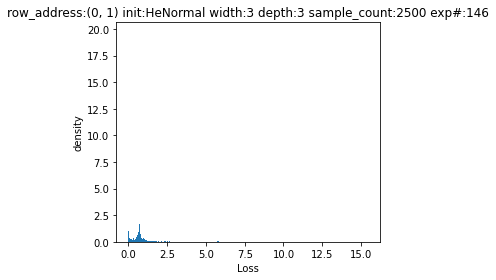


time elapsed:
416.8564411289999


experiment_number:  147
row_address:  (0, 1)
init:  HeNormal
width:  3
depth:  4

min =  3.099446303167497e-06
max =  15.424948692321777
median =  0.6931469440460205
mean =  0.8732287602121233
stdev =  1.1358720410981207
mad =  0.4241513194211932



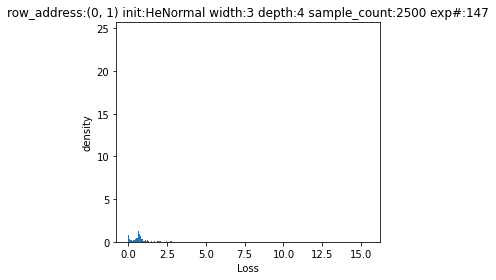


time elapsed:
462.70027290100006


experiment_number:  148
row_address:  (0, 1)
init:  HeNormal
width:  3
depth:  5

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  0.8242753824003143
stdev =  0.9219105775174345
mad =  0.33062206411666645



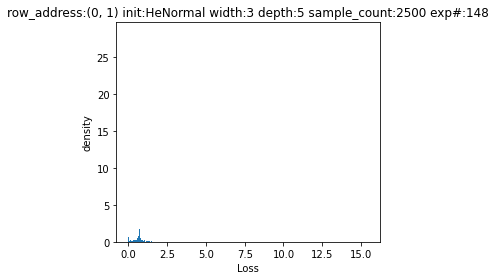


time elapsed:
513.0104420240002


experiment_number:  149
row_address:  (0, 1)
init:  HeNormal
width:  3
depth:  6

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  0.7787688192401927
stdev =  0.7680664069348182
mad =  0.23324022867530034



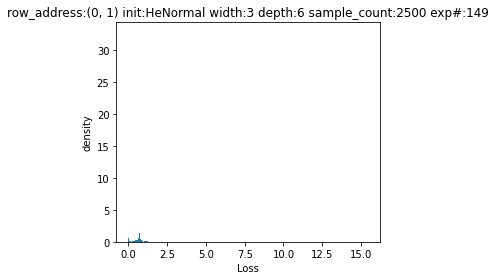


time elapsed:
564.3229416139998


experiment_number:  150
row_address:  (0, 1)
init:  HeNormal
width:  6
depth:  1

min =  0.00032859478960745037
max =  7.7214202880859375
median =  0.6931469440460205
mean =  0.9803574186805286
stdev =  1.0125439036700978
mad =  0.7129397469312425



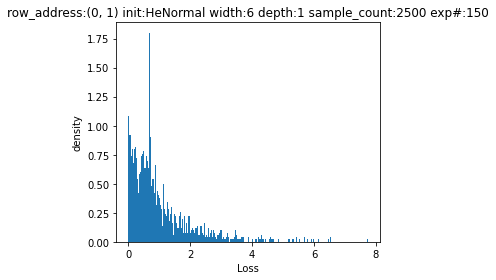


time elapsed:
314.93078561799985


experiment_number:  151
row_address:  (0, 1)
init:  HeNormal
width:  6
depth:  2

min =  5.1976599934278056e-05
max =  14.198447227478027
median =  0.6931469440460205
mean =  1.022605573371578
stdev =  1.1808777820657257
mad =  0.733387652739208



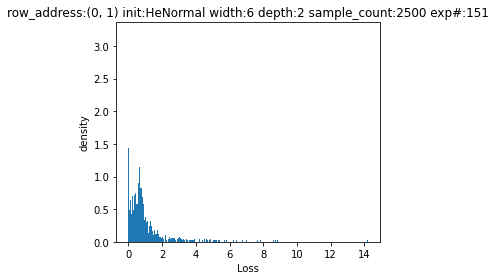


time elapsed:
361.7603660970003


experiment_number:  152
row_address:  (0, 1)
init:  HeNormal
width:  6
depth:  3

min =  -0.0
max =  14.229122161865234
median =  0.6931469440460205
mean =  0.9678981041151886
stdev =  1.0884083107774083
mad =  0.6363774051443482



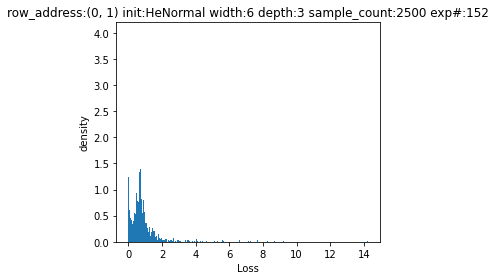


time elapsed:
409.543862599


experiment_number:  153
row_address:  (0, 1)
init:  HeNormal
width:  6
depth:  4

min =  -0.0
max =  14.929580688476562
median =  0.6931469440460205
mean =  0.9823392816079101
stdev =  1.151443791727195
mad =  0.6309255663685787



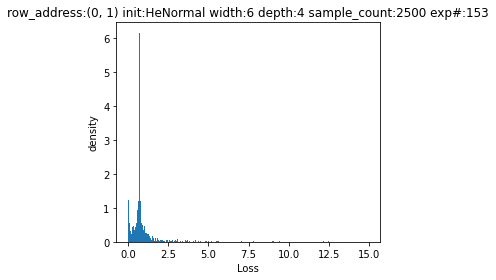


time elapsed:
460.28331536399946


experiment_number:  154
row_address:  (0, 1)
init:  HeNormal
width:  6
depth:  5

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  0.9119407594300395
stdev =  1.171994071661568
mad =  0.5293571893077342



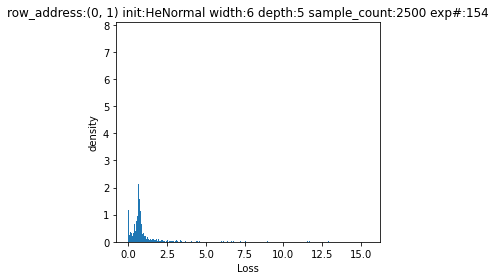


time elapsed:
509.69773909300056


experiment_number:  155
row_address:  (0, 1)
init:  HeNormal
width:  6
depth:  6

min =  -0.0
max =  14.77249813079834
median =  0.6931469440460205
mean =  0.8622870604432299
stdev =  1.0476515321717874
mad =  0.4480500838974752



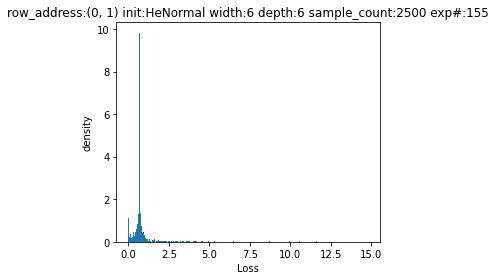


time elapsed:
557.4558617960001


experiment_number:  156
row_address:  (0, 1)
init:  HeNormal
width:  9
depth:  1

min =  7.820434984751046e-05
max =  6.378042221069336
median =  0.7008388936519623
mean =  1.0104778355252113
stdev =  0.988464940613115
mad =  0.7365886816485792



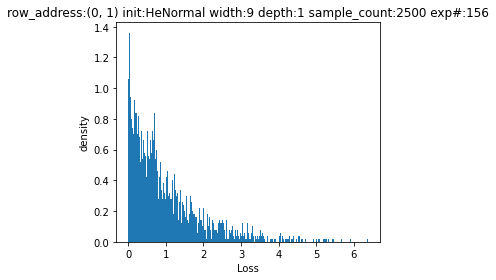


time elapsed:
311.1582687729997


experiment_number:  157
row_address:  (0, 1)
init:  HeNormal
width:  9
depth:  2

min =  3.701516834553331e-05
max =  11.662220001220703
median =  0.7067511677742004
mean =  1.0138888173163665
stdev =  1.0914264318002236
mad =  0.7193743979250891



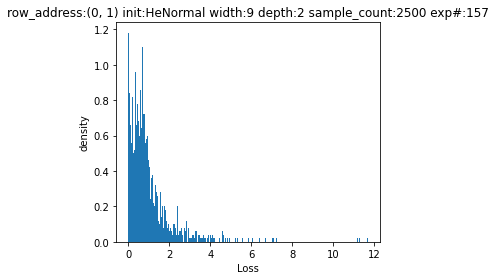


time elapsed:
360.5813758260001


experiment_number:  158
row_address:  (0, 1)
init:  HeNormal
width:  9
depth:  3

min =  7.373366679530591e-05
max =  12.243303298950195
median =  0.6982685923576355
mean =  0.9729110167745676
stdev =  1.0266731497159367
mad =  0.6602547018163069



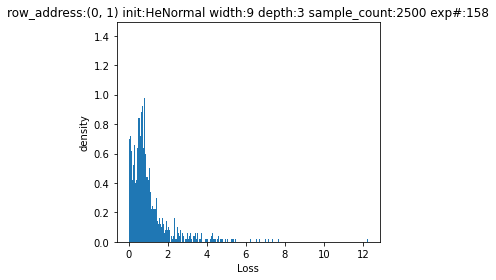


time elapsed:
412.4663726530007


experiment_number:  159
row_address:  (0, 1)
init:  HeNormal
width:  9
depth:  4

min =  7.510213436034974e-06
max =  12.160177230834961
median =  0.6931469440460205
mean =  0.9702654053246642
stdev =  1.0805863342212287
mad =  0.6443372077848682



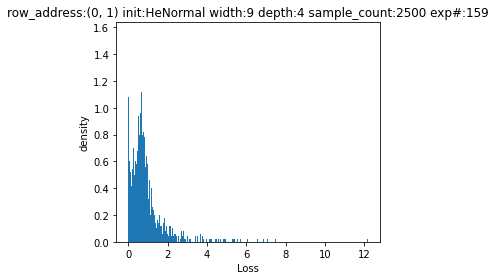


time elapsed:
461.5892700489994


experiment_number:  160
row_address:  (0, 1)
init:  HeNormal
width:  9
depth:  5

min =  4.0531240301788785e-06
max =  13.373403549194336
median =  0.6931469440460205
mean =  0.9572105293162732
stdev =  1.079538512036534
mad =  0.6177739702900051



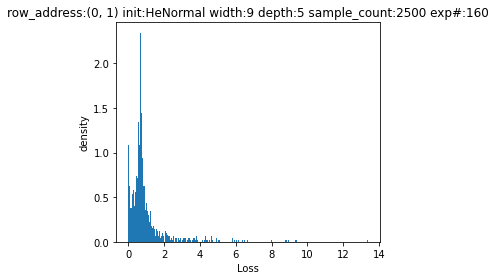


time elapsed:
511.7329798230003


experiment_number:  161
row_address:  (0, 1)
init:  HeNormal
width:  9
depth:  6

min =  2.0265599687263602e-06
max =  14.74852180480957
median =  0.6931350827217102
mean =  0.92190238244781
stdev =  1.0591832147466993
mad =  0.5547494438442856



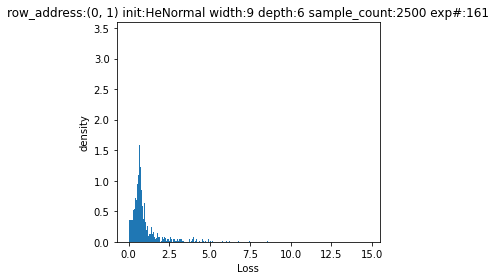


time elapsed:
563.7236031619996


experiment_number:  162
row_address:  (0, 1)
init:  HeNormal
width:  12
depth:  1

min =  7.546232518507168e-05
max =  7.376432418823242
median =  0.6787438690662384
mean =  0.9759641108741373
stdev =  0.979031165666958
mad =  0.7246955182179896



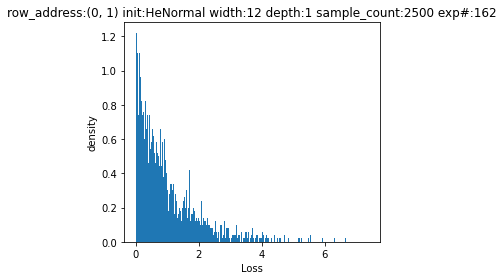


time elapsed:
316.9568266640008


experiment_number:  163
row_address:  (0, 1)
init:  HeNormal
width:  12
depth:  2

min =  0.00014252486289478838
max =  11.686257362365723
median =  0.6941468417644501
mean =  1.0166700689832213
stdev =  1.0864940497283457
mad =  0.7418342823903316



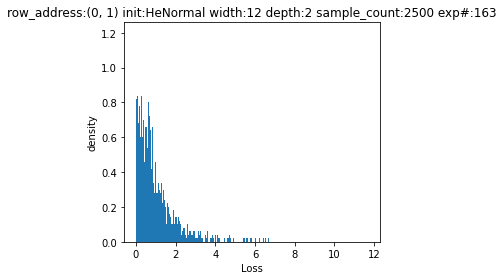


time elapsed:
364.60230835699986


experiment_number:  164
row_address:  (0, 1)
init:  HeNormal
width:  12
depth:  3

min =  1.8537215510150418e-05
max =  10.16411018371582
median =  0.715392529964447
mean =  1.0114980452771982
stdev =  1.101155349314428
mad =  0.7051625723966167



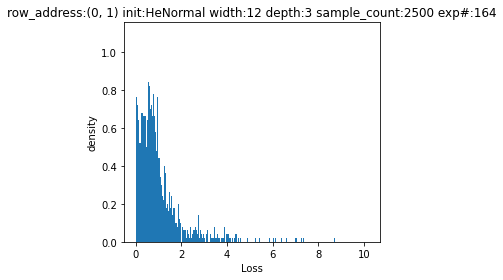


time elapsed:
407.1379259509995


experiment_number:  165
row_address:  (0, 1)
init:  HeNormal
width:  12
depth:  4

min =  -0.0
max =  11.780328750610352
median =  0.699392169713974
mean =  0.9658537721515983
stdev =  1.0273281594804609
mad =  0.6517688654326688



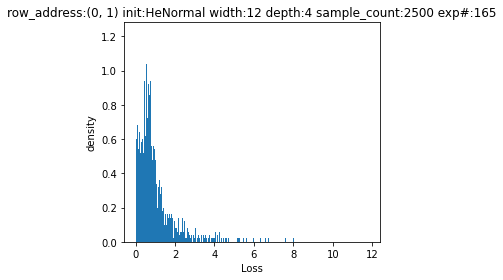


time elapsed:
452.08613759499895


experiment_number:  166
row_address:  (0, 1)
init:  HeNormal
width:  12
depth:  5

min =  3.993519385403488e-06
max =  12.728236198425293
median =  0.6885974407196045
mean =  0.9679804573354992
stdev =  1.0835859007132431
mad =  0.662979390232269



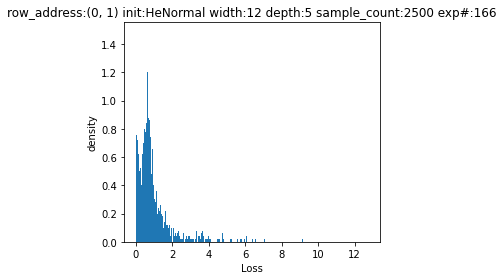


time elapsed:
500.3950048679999


experiment_number:  167
row_address:  (0, 1)
init:  HeNormal
width:  12
depth:  6

min =  2.217317342001479e-05
max =  14.776667594909668
median =  0.694331020116806
mean =  0.93814236422811
stdev =  1.0075119934014767
mad =  0.5934638152096802



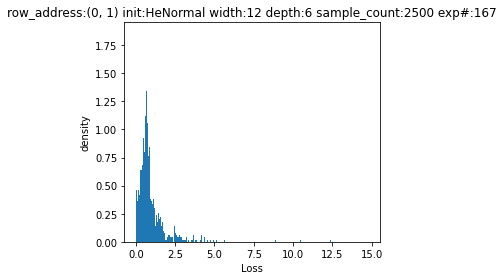


time elapsed:
549.1703500500007


experiment_number:  168
row_address:  (0, 1)
init:  HeNormal
width:  15
depth:  1

min =  0.0006639776984229684
max =  7.5752387046813965
median =  0.698198139667511
mean =  1.0229751713380217
stdev =  1.0308904786396085
mad =  0.7633565568969837



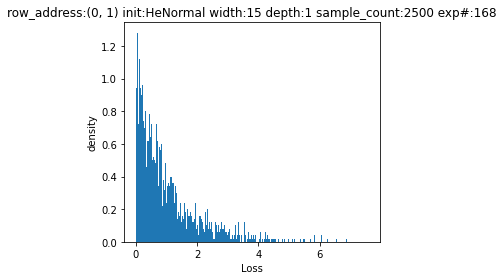


time elapsed:
306.6725963509998


experiment_number:  169
row_address:  (0, 1)
init:  HeNormal
width:  15
depth:  2

min =  6.270605081226677e-05
max =  8.859132766723633
median =  0.6849446892738342
mean =  0.9900752089436341
stdev =  1.0143851119229401
mad =  0.7137775226755119



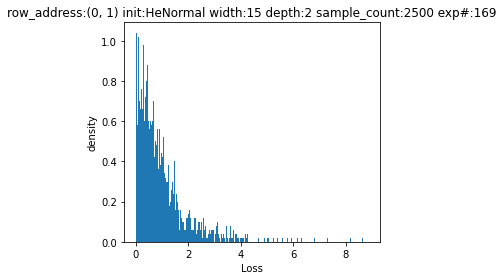


time elapsed:
355.359281635001


experiment_number:  170
row_address:  (0, 1)
init:  HeNormal
width:  15
depth:  3

min =  9.608730033505708e-05
max =  8.655105590820312
median =  0.662361353635788
mean =  0.9652983340385836
stdev =  1.0082054444014252
mad =  0.7016150669628044



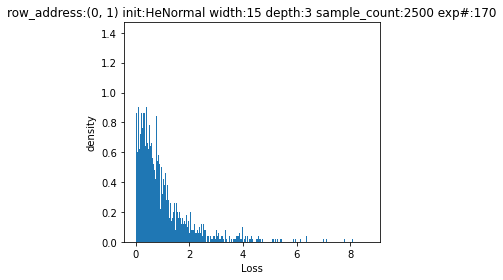


time elapsed:
403.4826579519995


experiment_number:  171
row_address:  (0, 1)
init:  HeNormal
width:  15
depth:  4

min =  0.00012744285049848258
max =  10.006227493286133
median =  0.6794213354587555
mean =  0.9859387838187046
stdev =  1.0646193510940583
mad =  0.6997337630941619



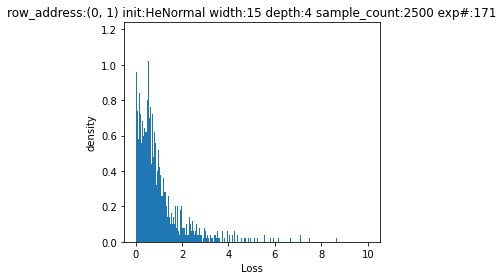


time elapsed:
452.5478841789991


experiment_number:  172
row_address:  (0, 1)
init:  HeNormal
width:  15
depth:  5

min =  4.11272912970162e-06
max =  10.282907485961914
median =  0.6718009114265442
mean =  0.9442449705101493
stdev =  1.013365864369095
mad =  0.6467156865331195



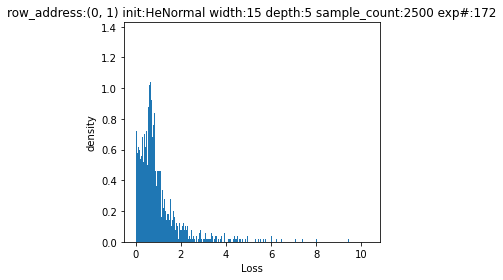


time elapsed:
499.1893059510003


experiment_number:  173
row_address:  (0, 1)
init:  HeNormal
width:  15
depth:  6

min =  1.1920928955078125e-07
max =  11.669514656066895
median =  0.6857672929763794
mean =  0.9155757569179986
stdev =  0.9854151153601787
mad =  0.5969583481009421



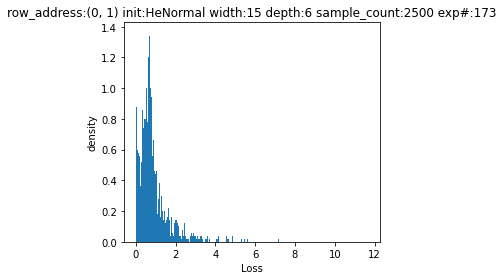


time elapsed:
548.9588029440001


experiment_number:  174
row_address:  (0, 1)
init:  HeNormal
width:  18
depth:  1

min =  0.0012277746573090553
max =  7.6311492919921875
median =  0.6611166894435883
mean =  1.016977507689409
stdev =  1.0236150897937644
mad =  0.7770142444131354



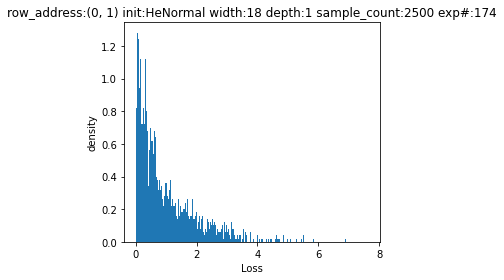


time elapsed:
306.0835455730012


experiment_number:  175
row_address:  (0, 1)
init:  HeNormal
width:  18
depth:  2

min =  0.0009973252890631557
max =  7.570312976837158
median =  0.6620330810546875
mean =  0.997934808954643
stdev =  1.0345372692434054
mad =  0.7511940325825978



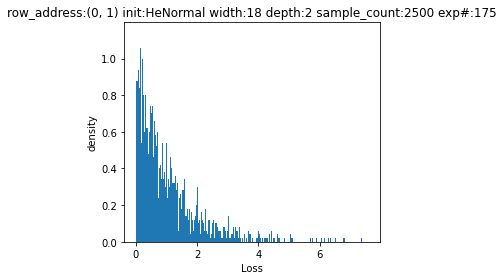


time elapsed:
355.43263343000035


experiment_number:  176
row_address:  (0, 1)
init:  HeNormal
width:  18
depth:  3

min =  4.977111530024558e-05
max =  9.43811321258545
median =  0.7016972005367279
mean =  0.9789166662574513
stdev =  0.9896367459956616
mad =  0.6954121568638633



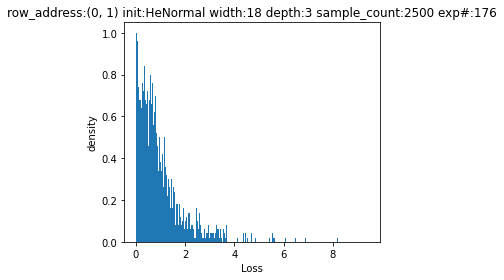


time elapsed:
402.8896387519999


experiment_number:  177
row_address:  (0, 1)
init:  HeNormal
width:  18
depth:  4

min =  9.048394713317975e-05
max =  12.508090019226074
median =  0.6775622069835663
mean =  0.9780445429797634
stdev =  1.0593199869002012
mad =  0.6962934981966068



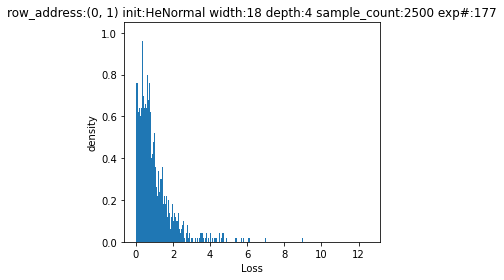


time elapsed:
451.4782289279992


experiment_number:  178
row_address:  (0, 1)
init:  HeNormal
width:  18
depth:  5

min =  2.062341991404537e-05
max =  10.903743743896484
median =  0.7034896314144135
mean =  1.0096448633544184
stdev =  1.1046464907791045
mad =  0.7112002031937394



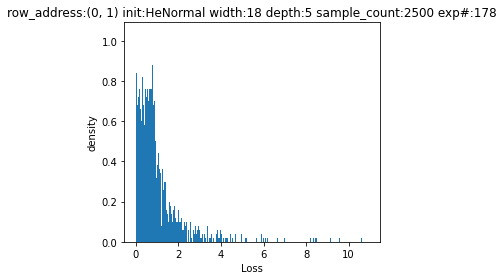


time elapsed:
500.79914861900033


experiment_number:  179
row_address:  (0, 1)
init:  HeNormal
width:  18
depth:  6

min =  1.8477456933396752e-06
max =  12.06561279296875
median =  0.7171894013881683
mean =  1.0073138341572347
stdev =  1.0781667626467248
mad =  0.6980611385584308



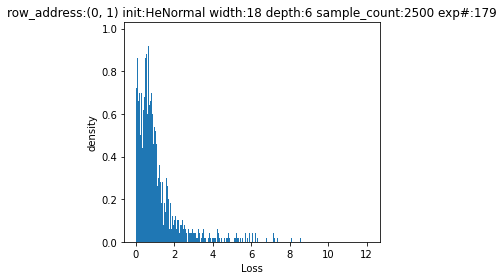


time elapsed:
550.2735788919999


experiment_number:  180
row_address:  (0, 1)
init:  HeUniform
width:  3
depth:  1

min =  0.0008140538702718914
max =  11.877742767333984
median =  0.6931469440460205
mean =  1.0194054289333057
stdev =  1.104374129824131
mad =  0.722447622105537



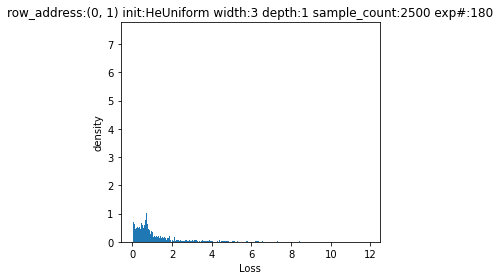


time elapsed:
307.2277298659992


experiment_number:  181
row_address:  (0, 1)
init:  HeUniform
width:  3
depth:  2

min =  5.960466182841628e-07
max =  11.288593292236328
median =  0.6931469440460205
mean =  0.9364385446213032
stdev =  1.0709679308541273
mad =  0.5869492222010769



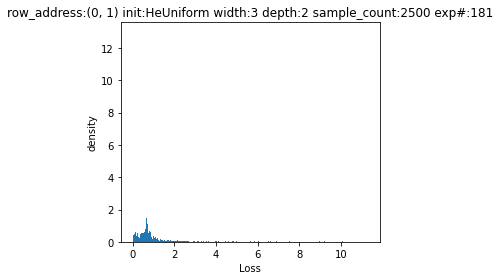


time elapsed:
354.79443926399836


experiment_number:  182
row_address:  (0, 1)
init:  HeUniform
width:  3
depth:  3

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  0.9172976108157777
stdev =  1.0903943338329993
mad =  0.5176755977064187



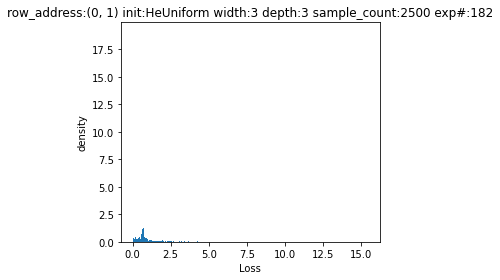


time elapsed:
403.5619087160012


experiment_number:  183
row_address:  (0, 1)
init:  HeUniform
width:  3
depth:  4

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  0.8880862481433413
stdev =  1.1917279651674615
mad =  0.4546946315569413



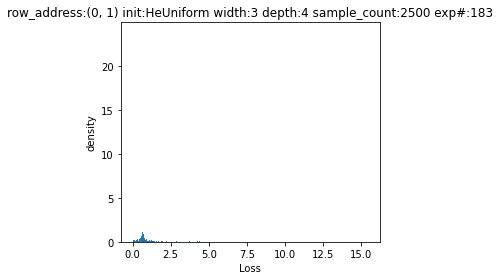


time elapsed:
451.8671203490012


experiment_number:  184
row_address:  (0, 1)
init:  HeUniform
width:  3
depth:  5

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  0.8178063680013123
stdev =  0.8812816646801647
mad =  0.31789358834127235



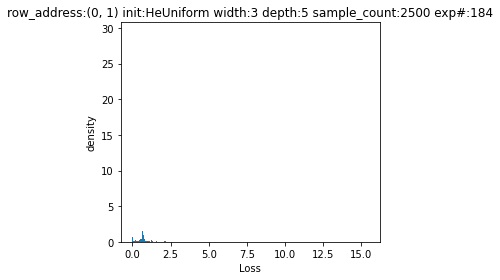


time elapsed:
501.28389995999896


experiment_number:  185
row_address:  (0, 1)
init:  HeUniform
width:  3
depth:  6

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  0.80221916165271
stdev =  0.9673108367645126
mad =  0.27994698735504653



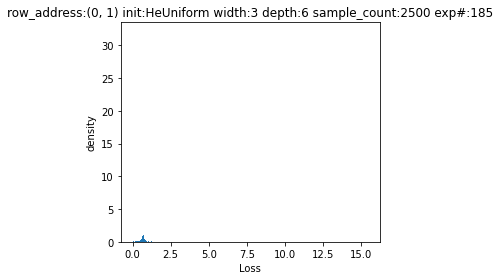


time elapsed:
549.7372388270014


experiment_number:  186
row_address:  (0, 1)
init:  HeUniform
width:  6
depth:  1

min =  0.00032191688660532236
max =  8.750136375427246
median =  0.6952570676803589
mean =  1.0144904489367501
stdev =  1.0250213523474867
mad =  0.7343469842646944



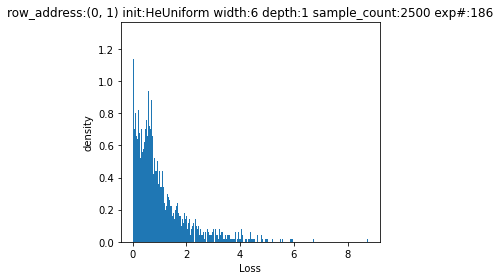


time elapsed:
308.54285370199796


experiment_number:  187
row_address:  (0, 1)
init:  HeUniform
width:  6
depth:  2

min =  1.9073504518019035e-06
max =  15.424948692321777
median =  0.6931469440460205
mean =  0.959434959463238
stdev =  1.055743955098397
mad =  0.6619316957865815



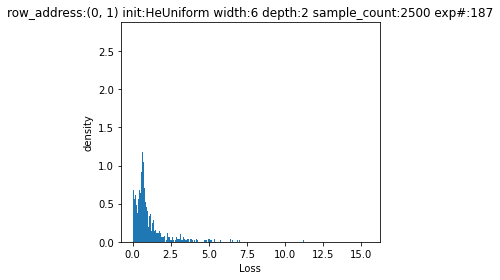


time elapsed:
358.823142164998


experiment_number:  188
row_address:  (0, 1)
init:  HeUniform
width:  6
depth:  3

min =  5.424037226475775e-06
max =  15.424948692321777
median =  0.6931469440460205
mean =  0.9562959082879728
stdev =  1.132423464351415
mad =  0.6370380454682943



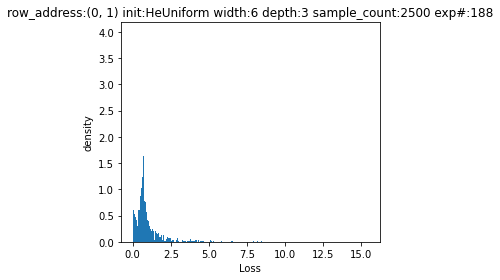


time elapsed:
408.7396550480007


experiment_number:  189
row_address:  (0, 1)
init:  HeUniform
width:  6
depth:  4

min =  2.2530810383614153e-05
max =  14.727629661560059
median =  0.6931469440460205
mean =  0.979455820836543
stdev =  1.155174378880135
mad =  0.6206310517751142



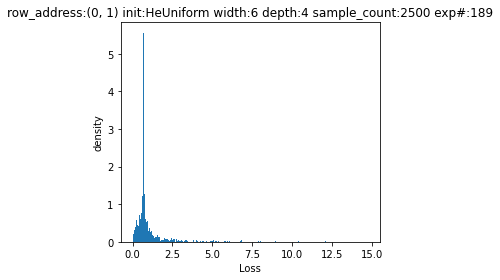


time elapsed:
455.8558797909973


experiment_number:  190
row_address:  (0, 1)
init:  HeUniform
width:  6
depth:  5

min =  -0.0
max =  15.168067932128906
median =  0.6931469440460205
mean =  0.8927024588593638
stdev =  1.0078387807437093
mad =  0.48465290877265116



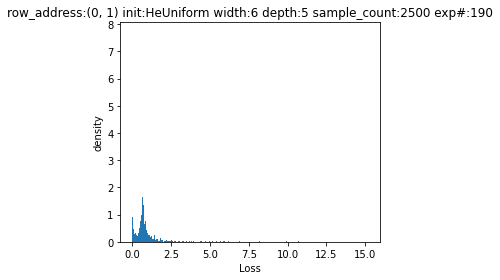


time elapsed:
501.5512696930018


experiment_number:  191
row_address:  (0, 1)
init:  HeUniform
width:  6
depth:  6

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  0.892478292658399
stdev =  1.0664478390263508
mad =  0.49204948232869383



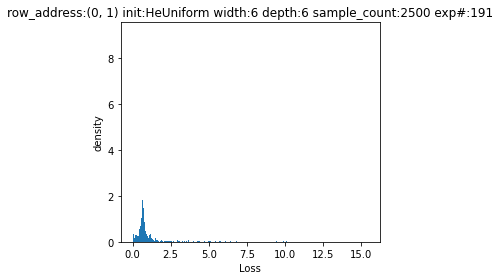


time elapsed:
547.4829284019979


experiment_number:  192
row_address:  (0, 1)
init:  HeUniform
width:  9
depth:  1

min =  0.0008846260607242584
max =  7.579780101776123
median =  0.7434934973716736
mean =  1.0678899005004205
stdev =  1.0688750197288601
mad =  0.7824225424480985



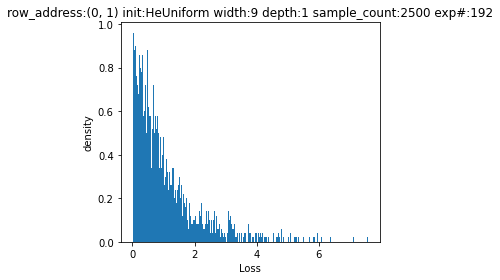


time elapsed:
305.1872915690001


experiment_number:  193
row_address:  (0, 1)
init:  HeUniform
width:  9
depth:  2

min =  0.0001275620743399486
max =  8.452085494995117
median =  0.6931469440460205
mean =  1.0198874391171848
stdev =  1.0854943208540875
mad =  0.7353541910982675



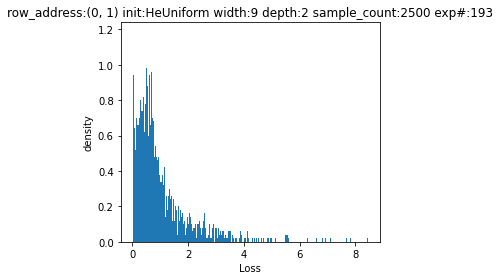


time elapsed:
354.2227782509981


experiment_number:  194
row_address:  (0, 1)
init:  HeUniform
width:  9
depth:  3

min =  6.07969241173123e-06
max =  12.306721687316895
median =  0.6956983804702759
mean =  0.9912264940140203
stdev =  1.1136159464312696
mad =  0.6847025305687372



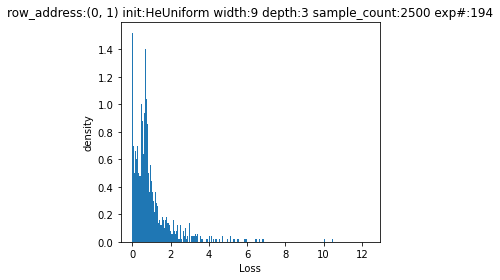


time elapsed:
403.1030749499987


experiment_number:  195
row_address:  (0, 1)
init:  HeUniform
width:  9
depth:  4

min =  2.0742631022585556e-05
max =  15.052042007446289
median =  0.6909380555152893
mean =  0.9461272677082525
stdev =  1.0611337823015146
mad =  0.6218640312877312



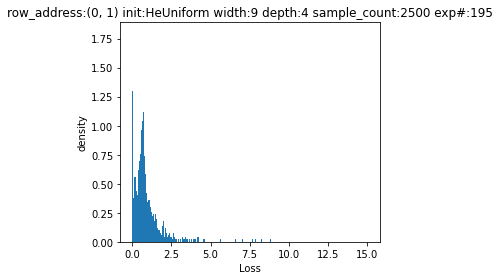


time elapsed:
452.75621163899996


experiment_number:  196
row_address:  (0, 1)
init:  HeUniform
width:  9
depth:  5

min =  -0.0
max =  9.55594253540039
median =  0.6860535144805908
mean =  0.930402075721439
stdev =  1.0316653259871602
mad =  0.5958310419605956



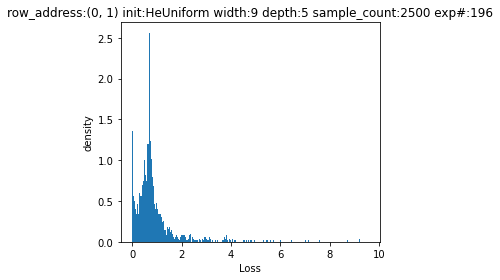


time elapsed:
503.18277852699975


experiment_number:  197
row_address:  (0, 1)
init:  HeUniform
width:  9
depth:  6

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  0.9139403841698557
stdev =  1.060935679797419
mad =  0.5512196083050042



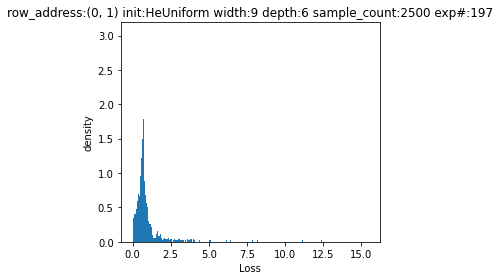


time elapsed:
552.419241880998


experiment_number:  198
row_address:  (0, 1)
init:  HeUniform
width:  12
depth:  1

min =  0.0003579303447622806
max =  6.774316787719727
median =  0.7046996057033539
mean =  1.0397433802156126
stdev =  1.0341296742652644
mad =  0.7763106311217786



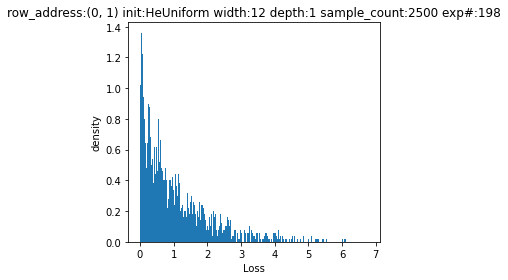


time elapsed:
306.7750475399989


experiment_number:  199
row_address:  (0, 1)
init:  HeUniform
width:  12
depth:  2

min =  0.0005711159319616854
max =  7.783056735992432
median =  0.6778296232223511
mean =  0.9917395894785179
stdev =  1.0342442991833385
mad =  0.7288305442253383



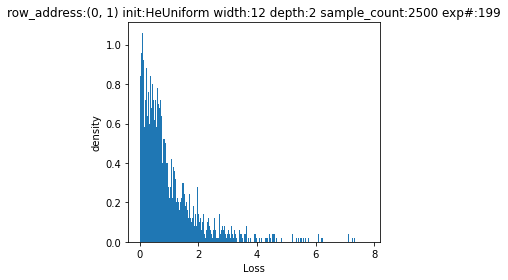


time elapsed:
356.6782341469989


experiment_number:  200
row_address:  (0, 1)
init:  HeUniform
width:  12
depth:  3

min =  0.00028876657597720623
max =  10.631671905517578
median =  0.708845853805542
mean =  1.027567846294865
stdev =  1.1123566906149192
mad =  0.7426400143713942



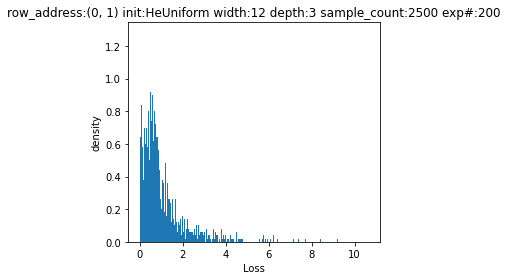


time elapsed:
404.19855662600094


experiment_number:  201
row_address:  (0, 1)
init:  HeUniform
width:  12
depth:  4

min =  -0.0
max =  12.077801704406738
median =  0.6936395168304443
mean =  0.9883796312979648
stdev =  1.1084359082352602
mad =  0.6823111734270773



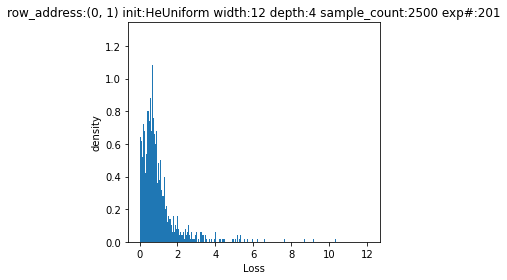


time elapsed:
451.7968530649996


experiment_number:  202
row_address:  (0, 1)
init:  HeUniform
width:  12
depth:  5

min =  -0.0
max =  10.950409889221191
median =  0.6820982992649078
mean =  0.9253537667524783
stdev =  0.940932030875812
mad =  0.6002793609285343



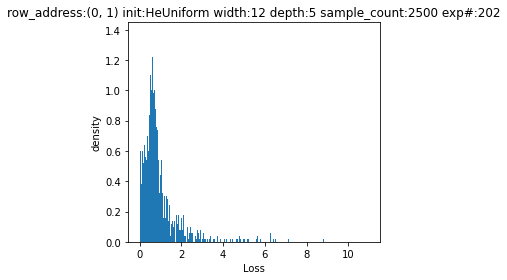


time elapsed:
502.1683710819998


experiment_number:  203
row_address:  (0, 1)
init:  HeUniform
width:  12
depth:  6

min =  -0.0
max =  15.424948692321777
median =  0.6940668821334839
mean =  0.9543503261686361
stdev =  1.1630096496875142
mad =  0.6172644784840344



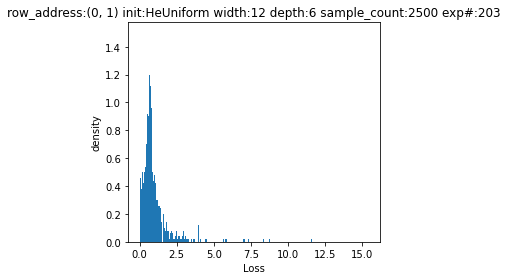


time elapsed:
548.6949497360001


experiment_number:  204
row_address:  (0, 1)
init:  HeUniform
width:  15
depth:  1

min =  0.0017259701853618026
max =  7.685300827026367
median =  0.647642195224762
mean =  0.9852814583692234
stdev =  1.0001913027523779
mad =  0.7497005678692819



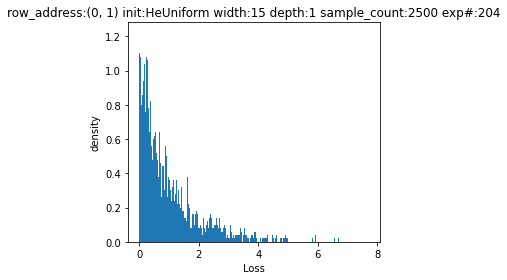


time elapsed:
306.5140115380018


experiment_number:  205
row_address:  (0, 1)
init:  HeUniform
width:  15
depth:  2

min =  3.933984044124372e-05
max =  10.853647232055664
median =  0.6812772154808044
mean =  0.9920412950222454
stdev =  1.0110896008521104
mad =  0.7247909426101692



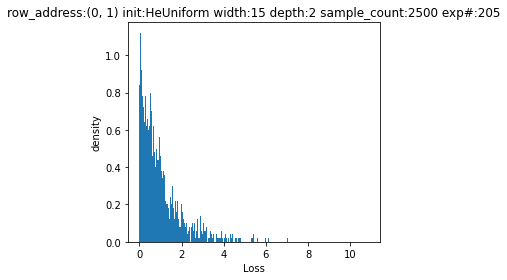


time elapsed:
356.9993880789989


experiment_number:  206
row_address:  (0, 1)
init:  HeUniform
width:  15
depth:  3

min =  1.6689314179529902e-06
max =  7.834788799285889
median =  0.6746189892292023
mean =  0.9905152167269813
stdev =  1.0233170908081064
mad =  0.7191991579779091



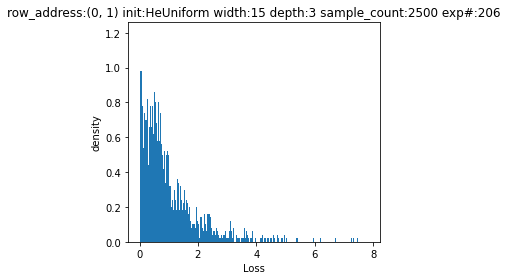


time elapsed:
404.7846953219996


experiment_number:  207
row_address:  (0, 1)
init:  HeUniform
width:  15
depth:  4

min =  9.179157132166438e-06
max =  12.593897819519043
median =  0.6882836818695068
mean =  0.9801420763947175
stdev =  1.0789000539488092
mad =  0.6972141300830765



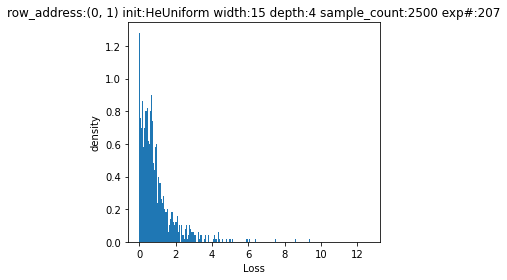


time elapsed:
456.17778402399927


experiment_number:  208
row_address:  (0, 1)
init:  HeUniform
width:  15
depth:  5

min =  1.1920935776288388e-06
max =  11.216506958007812
median =  0.686626523733139
mean =  0.9476590232812155
stdev =  1.0134600667534324
mad =  0.6354160574013801



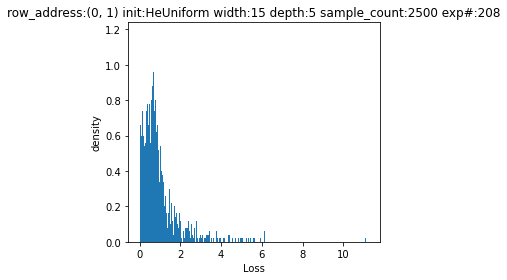


time elapsed:
504.4135050240002


experiment_number:  209
row_address:  (0, 1)
init:  HeUniform
width:  15
depth:  6

min =  7.271793037944008e-06
max =  10.178241729736328
median =  0.6961844265460968
mean =  0.9649415398938261
stdev =  1.0367998600514972
mad =  0.6428012053470232



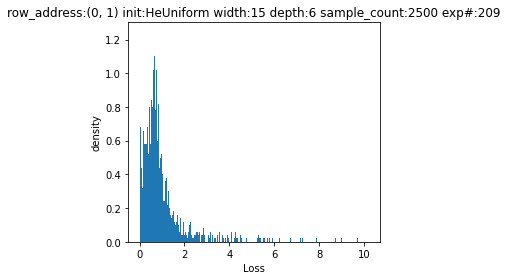


time elapsed:
552.2936568229998


experiment_number:  210
row_address:  (0, 1)
init:  HeUniform
width:  18
depth:  1

min =  0.00029997556703165174
max =  7.8371262550354
median =  0.6965757012367249
mean =  1.0267484513942153
stdev =  1.0310457648336562
mad =  0.774005049157025



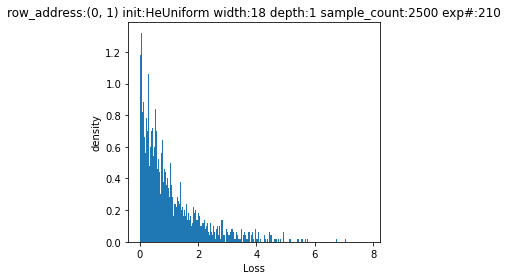


time elapsed:
306.6388308280002


experiment_number:  211
row_address:  (0, 1)
init:  HeUniform
width:  18
depth:  2

min =  0.0008554540108889341
max =  8.912997245788574
median =  0.683618038892746
mean =  0.9974544820611365
stdev =  1.026694868040567
mad =  0.7341734589901019



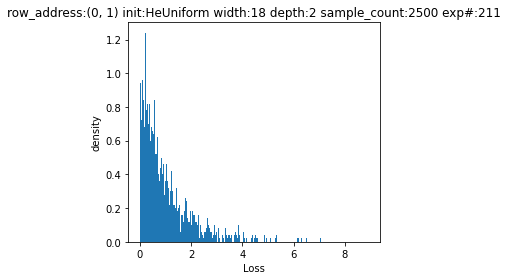


time elapsed:
357.93366991499715


experiment_number:  212
row_address:  (0, 1)
init:  HeUniform
width:  18
depth:  3

min =  3.4570753086882178e-06
max =  9.419171333312988
median =  0.7021157741546631
mean =  0.9830383193375566
stdev =  1.0248177919773525
mad =  0.6998265038239531



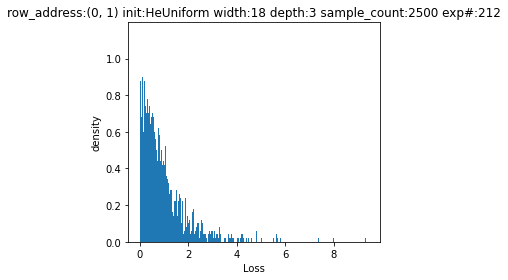


time elapsed:
407.8717507680012


experiment_number:  213
row_address:  (0, 1)
init:  HeUniform
width:  18
depth:  4

min =  0.0001428825344191864
max =  11.318921089172363
median =  0.6710869371891022
mean =  0.9485369585593929
stdev =  0.9988913868212507
mad =  0.6674571641352272



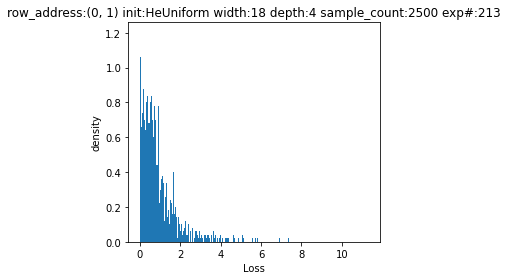


time elapsed:
462.3918217190003


experiment_number:  214
row_address:  (0, 1)
init:  HeUniform
width:  18
depth:  5

min =  1.1324889328534482e-06
max =  13.097088813781738
median =  0.703404039144516
mean =  1.0248666287187043
stdev =  1.1536158599943547
mad =  0.7305596399019618



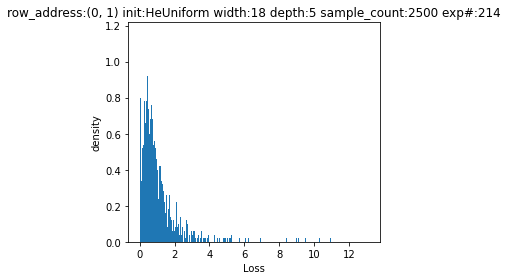


time elapsed:
511.85839473800297


experiment_number:  215
row_address:  (0, 1)
init:  HeUniform
width:  18
depth:  6

min =  3.993519385403488e-06
max =  15.32355785369873
median =  0.6928101778030396
mean =  0.9919502710586843
stdev =  1.154799065989864
mad =  0.6926358830571928



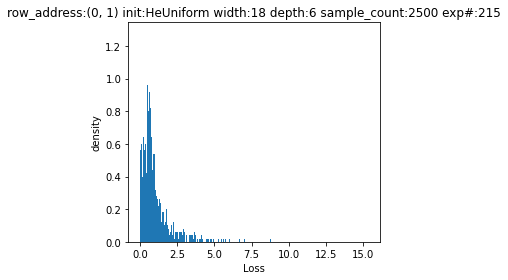


time elapsed:
556.2292251670005


experiment_number:  216
row_address:  (0, 1)
init:  normal
width:  3
depth:  1

min =  0.003929876256734133
max =  5.254520416259766
median =  0.6931469440460205
mean =  0.7458119341487065
stdev =  0.3736622453597147
mad =  0.23044670335780623



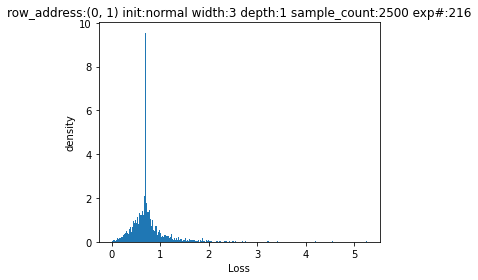


time elapsed:
305.9769891830001


experiment_number:  217
row_address:  (0, 1)
init:  normal
width:  3
depth:  2

min =  0.03273288160562515
max =  5.584901332855225
median =  0.6931469440460205
mean =  0.7119042765036225
stdev =  0.22723637091751656
mad =  0.10796823616749457



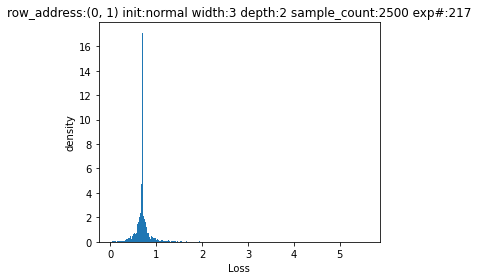


time elapsed:
356.3508528150014


experiment_number:  218
row_address:  (0, 1)
init:  normal
width:  3
depth:  3

min =  0.10917814821004868
max =  2.8291990756988525
median =  0.6931469440460205
mean =  0.7035798568576574
stdev =  0.13563445175343508
mad =  0.0572088291447166



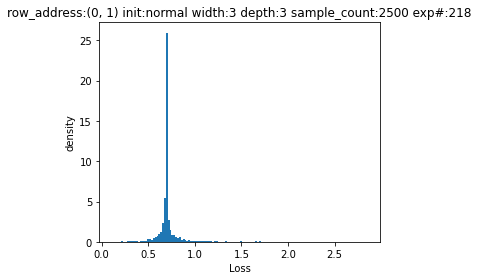


time elapsed:
403.643544241997


experiment_number:  219
row_address:  (0, 1)
init:  normal
width:  3
depth:  4

min =  0.08759602159261703
max =  3.285161018371582
median =  0.6931469440460205
mean =  0.696351206356287
stdev =  0.10474474569592801
mad =  0.027778446156378322



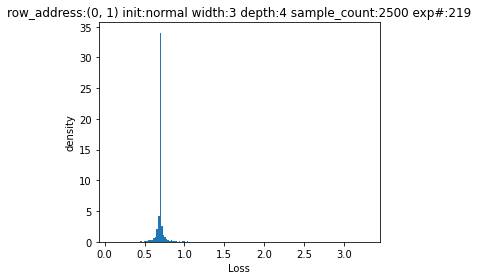


time elapsed:
451.78746298900296


experiment_number:  220
row_address:  (0, 1)
init:  normal
width:  3
depth:  5

min =  0.286886066198349
max =  1.4409469366073608
median =  0.6931469440460205
mean =  0.6941858184576034
stdev =  0.04726539891051403
mad =  0.013354212574062743



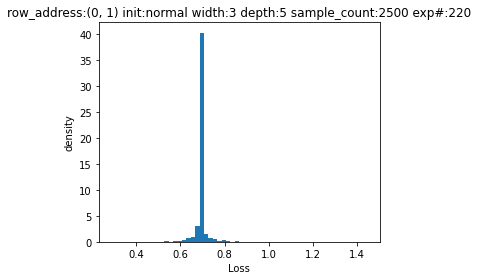


time elapsed:
501.8840226619941


experiment_number:  221
row_address:  (0, 1)
init:  normal
width:  3
depth:  6

min =  0.07759314030408859
max =  1.3535633087158203
median =  0.6931469440460205
mean =  0.6931691594690085
stdev =  0.031749781806905374
mad =  0.0062949792653273625



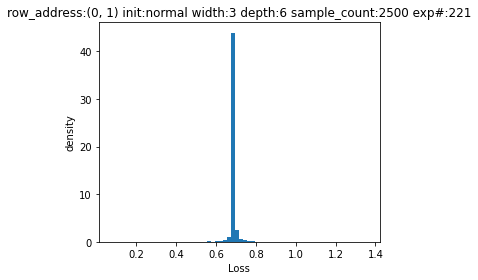


time elapsed:
551.0069908110017


experiment_number:  222
row_address:  (0, 1)
init:  normal
width:  6
depth:  1

min =  0.0036245626397430897
max =  5.452713966369629
median =  0.6931469440460205
mean =  0.7945086001794786
stdev =  0.5164928048338926
mad =  0.3565897008549914



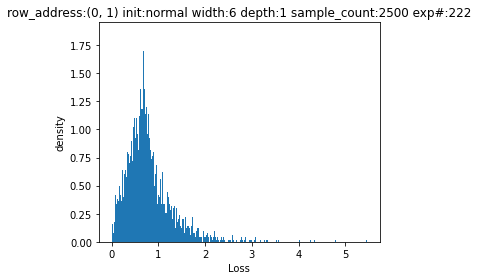


time elapsed:
306.7781179700032


experiment_number:  223
row_address:  (0, 1)
init:  normal
width:  6
depth:  2

min =  0.0030549291986972094
max =  7.305661201477051
median =  0.6931469440460205
mean =  0.7772697710742242
stdev =  0.4705013462989086
mad =  0.2910683122844669



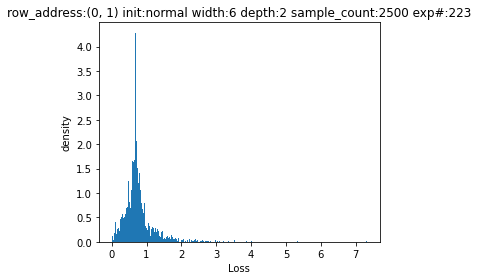


time elapsed:
355.84712846299954


experiment_number:  224
row_address:  (0, 1)
init:  normal
width:  6
depth:  3

min =  0.0009492371464148164
max =  6.722011566162109
median =  0.6931469440460205
mean =  0.7306365386069752
stdev =  0.36903947111274066
mad =  0.20569001770016898



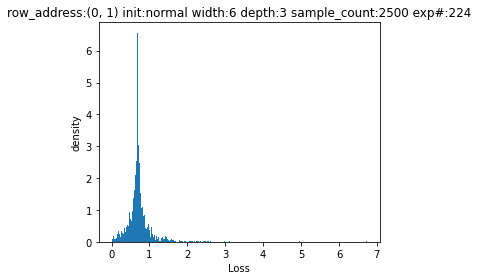


time elapsed:
404.0686710910013


experiment_number:  225
row_address:  (0, 1)
init:  normal
width:  6
depth:  4

min =  0.012803029268980026
max =  5.816590785980225
median =  0.6931469440460205
mean =  0.7252283498764038
stdev =  0.302543048246038
mad =  0.15661476340385772



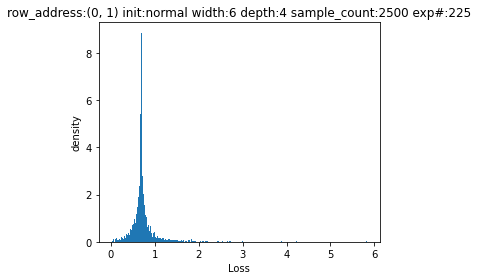


time elapsed:
452.5882077580027


experiment_number:  226
row_address:  (0, 1)
init:  normal
width:  6
depth:  5

min =  0.0035462600644677877
max =  4.814753532409668
median =  0.6931469440460205
mean =  0.7246364043108188
stdev =  0.27323171523646866
mad =  0.12409069475267503



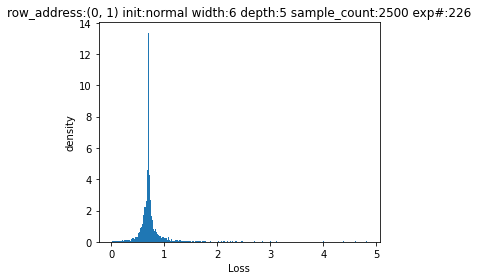


time elapsed:
502.97648531800223


experiment_number:  227
row_address:  (0, 1)
init:  normal
width:  6
depth:  6

min =  0.017071781679987907
max =  4.438355922698975
median =  0.6931469440460205
mean =  0.7115010251186789
stdev =  0.22669669357262476
mad =  0.09743053729830267



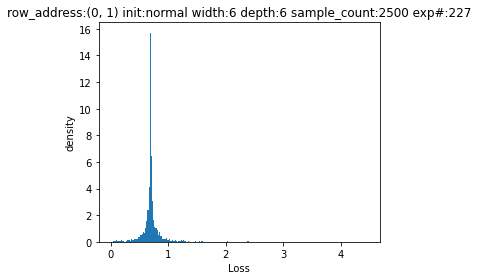


time elapsed:
553.733601287


experiment_number:  228
row_address:  (0, 1)
init:  normal
width:  9
depth:  1

min =  0.0017429273575544357
max =  4.765515327453613
median =  0.7013830840587616
mean =  0.8488856522977352
stdev =  0.6385126933433657
mad =  0.465905937908361



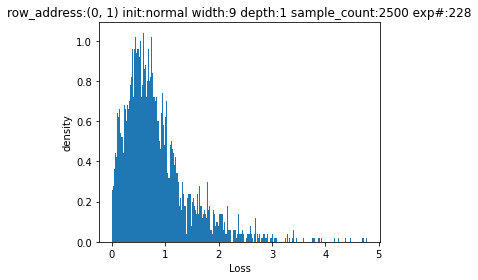


time elapsed:
307.562347127001


experiment_number:  229
row_address:  (0, 1)
init:  normal
width:  9
depth:  2

min =  0.0014948687748983502
max =  5.7075605392456055
median =  0.6931469440460205
mean =  0.8417917569717858
stdev =  0.6728714664885073
mad =  0.4466943913733744



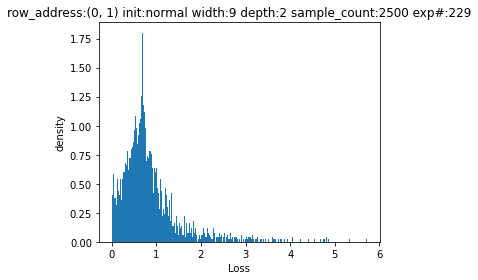


time elapsed:
357.5015950149973


experiment_number:  230
row_address:  (0, 1)
init:  normal
width:  9
depth:  3

min =  0.00024500509607605636
max =  10.997539520263672
median =  0.6882229745388031
mean =  0.8438331643051351
stdev =  0.727076016667428
mad =  0.4371581043905195



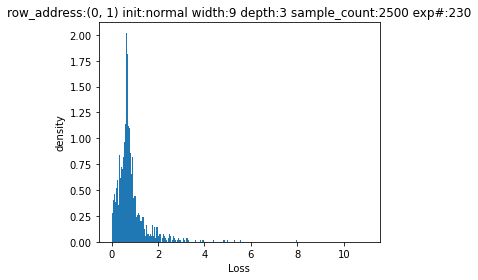


time elapsed:
407.254749669999


experiment_number:  231
row_address:  (0, 1)
init:  normal
width:  9
depth:  4

min =  5.960466182841628e-07
max =  13.979399681091309
median =  0.6931469440460205
mean =  0.8868983866721625
stdev =  0.9443822321425636
mad =  0.49665274353281413



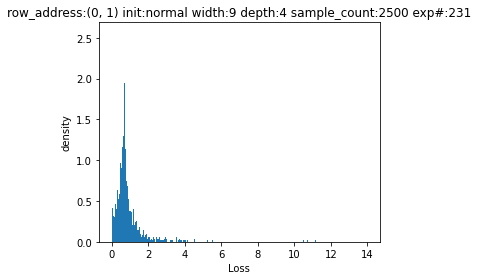


time elapsed:
453.8529082929963


experiment_number:  232
row_address:  (0, 1)
init:  normal
width:  9
depth:  5

min =  -0.0
max =  12.602922439575195
median =  0.6945264041423798
mean =  0.8883597827133694
stdev =  0.92521133500076
mad =  0.4829709709333988



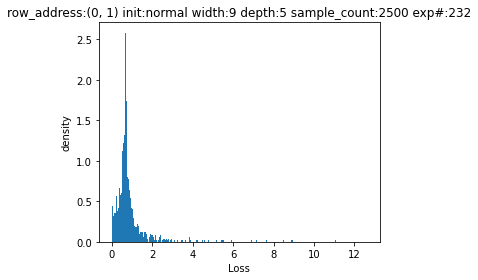


time elapsed:
503.6850527820061


experiment_number:  233
row_address:  (0, 1)
init:  normal
width:  9
depth:  6

min =  -0.0
max =  14.077404975891113
median =  0.6931443214416504
mean =  0.8592033478468882
stdev =  0.864517289688985
mad =  0.4542605114957434



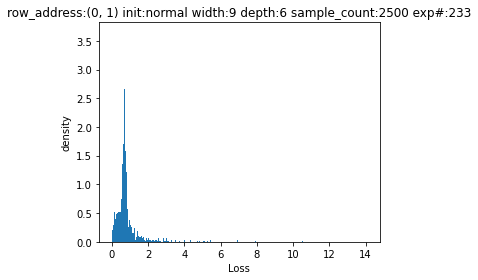


time elapsed:
550.9617351039997


experiment_number:  234
row_address:  (0, 1)
init:  normal
width:  12
depth:  1

min =  0.00717585813254118
max =  5.639011859893799
median =  0.6890524625778198
mean =  0.8958023626893759
stdev =  0.7804340126962623
mad =  0.5683756740583944



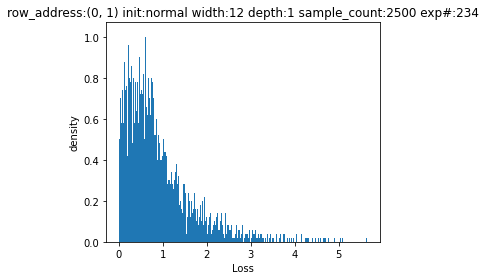


time elapsed:
307.96274654100125


experiment_number:  235
row_address:  (0, 1)
init:  normal
width:  12
depth:  2

min =  5.4837775678606704e-05
max =  7.603699684143066
median =  0.6856070160865784
mean =  0.9455203297910936
stdev =  0.9255309524706152
mad =  0.6485069108065642



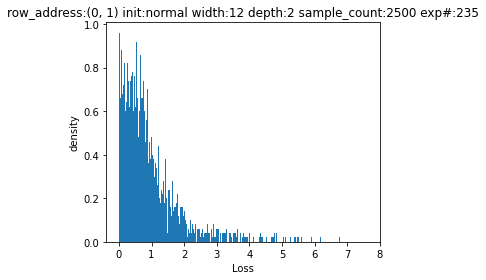


time elapsed:
357.00066415599576


experiment_number:  236
row_address:  (0, 1)
init:  normal
width:  12
depth:  3

min =  5.960466182841628e-07
max =  14.296852111816406
median =  0.6858207285404205
mean =  1.0157084081021
stdev =  1.19861530919547
mad =  0.7543222158551015



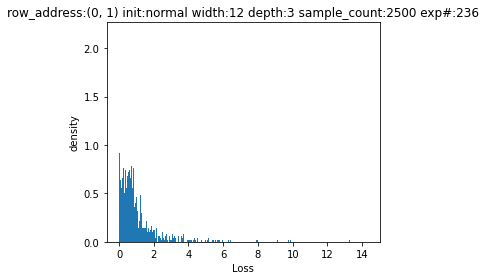


time elapsed:
406.327978856003


experiment_number:  237
row_address:  (0, 1)
init:  normal
width:  12
depth:  4

min =  1.0728841743912199e-06
max =  15.355938911437988
median =  0.6945943236351013
mean =  1.0921561376252915
stdev =  1.3912926101665875
mad =  0.8568916577886524



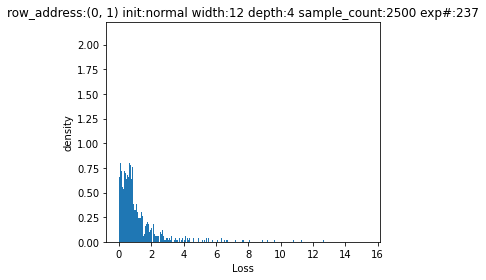


time elapsed:
455.8634908909953


experiment_number:  238
row_address:  (0, 1)
init:  normal
width:  12
depth:  5

min =  -0.0
max =  15.424948692321777
median =  0.6886092722415924
mean =  1.1813816620948145
stdev =  1.6870038686149988
mad =  1.0136417684723464



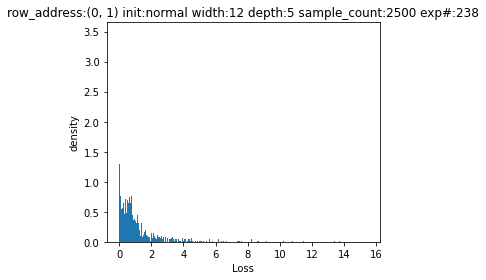


time elapsed:
511.2790784960016


experiment_number:  239
row_address:  (0, 1)
init:  normal
width:  12
depth:  6

min =  -0.0
max =  15.424948692321777
median =  0.6987787485122681
mean =  1.317011033682112
stdev =  2.0363448934174744
mad =  1.1884367215285263



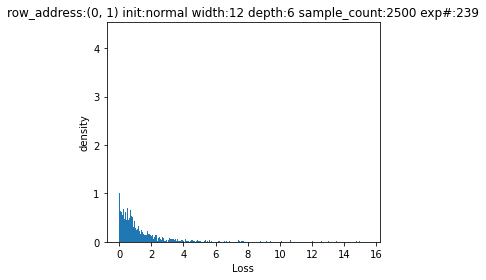


time elapsed:
558.3085520570021


experiment_number:  240
row_address:  (0, 1)
init:  normal
width:  15
depth:  1

min =  0.0010417163139209151
max =  6.613476276397705
median =  0.7104726433753967
mean =  0.9587769893439952
stdev =  0.8597116730439402
mad =  0.6481308942018684



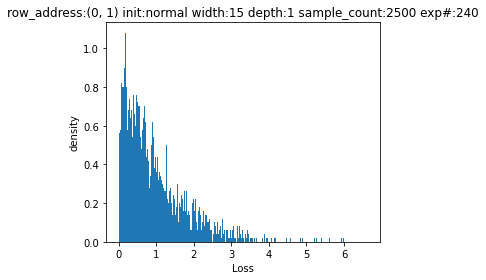


time elapsed:
308.1742607240012


experiment_number:  241
row_address:  (0, 1)
init:  normal
width:  15
depth:  2

min =  6.890534132253379e-05
max =  12.670646667480469
median =  0.6992304027080536
mean =  1.0657404571240303
stdev =  1.22889176916483
mad =  0.837038585459284



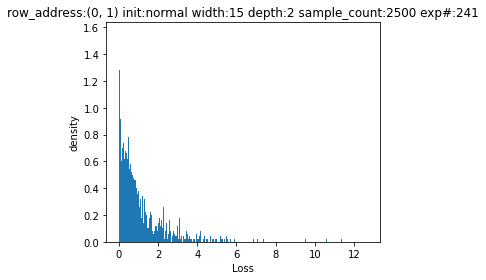


time elapsed:
357.8820699409989


experiment_number:  242
row_address:  (0, 1)
init:  normal
width:  15
depth:  3

min =  -0.0
max =  13.807066917419434
median =  0.6953372359275818
mean =  1.253347756385833
stdev =  1.5797127019112098
mad =  1.1032798472411813



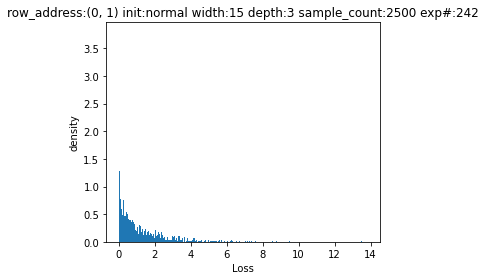


time elapsed:
406.5708063109996


experiment_number:  243
row_address:  (0, 1)
init:  normal
width:  15
depth:  4

min =  -0.0
max =  15.424948692321777
median =  0.6537920534610748
mean =  1.5394720066923608
stdev =  2.3001953319317154
mad =  1.5416955103833125



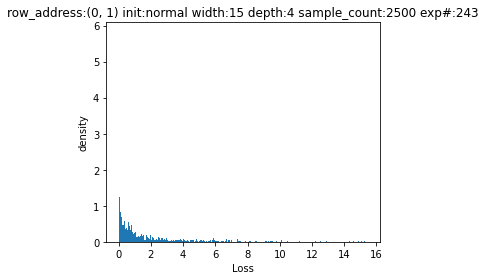


time elapsed:
457.0505964069962


experiment_number:  244
row_address:  (0, 1)
init:  normal
width:  15
depth:  5

min =  -0.0
max =  15.424948692321777
median =  0.6894473135471344
mean =  1.8983053114448587
stdev =  2.9431998804075117
mad =  2.004347788749666



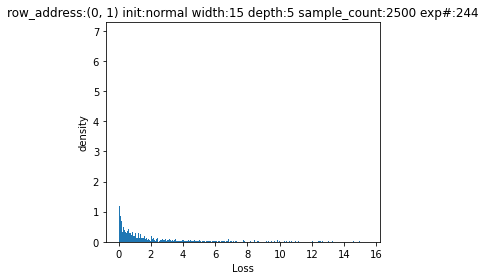


time elapsed:
504.18959021799674


experiment_number:  245
row_address:  (0, 1)
init:  normal
width:  15
depth:  6

min =  -0.0
max =  15.424948692321777
median =  0.6866790056228638
mean =  2.24091393010383
stdev =  3.5647317461758403
mad =  2.476771675333121



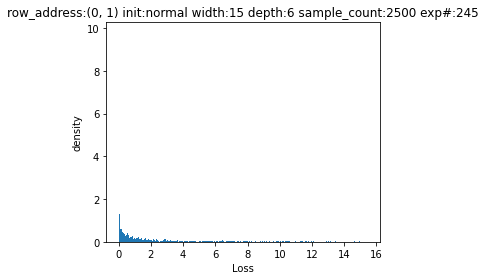


time elapsed:
554.3305203759955


experiment_number:  246
row_address:  (0, 1)
init:  normal
width:  18
depth:  1

min =  0.000722072902135551
max =  6.2237019538879395
median =  0.6939736306667328
mean =  0.966855939875124
stdev =  0.9228419907208795
mad =  0.6871596558667652



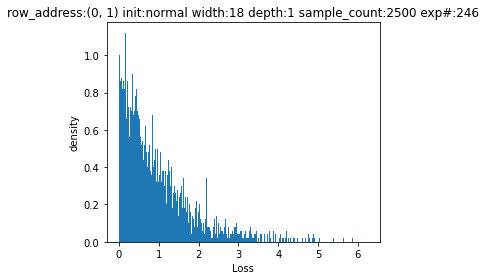


time elapsed:
310.0962044520056


experiment_number:  247
row_address:  (0, 1)
init:  normal
width:  18
depth:  2

min =  1.2278632311790716e-05
max =  11.088449478149414
median =  0.6918677389621735
mean =  1.1853616851329742
stdev =  1.4150939812639227
mad =  1.0167232138628013



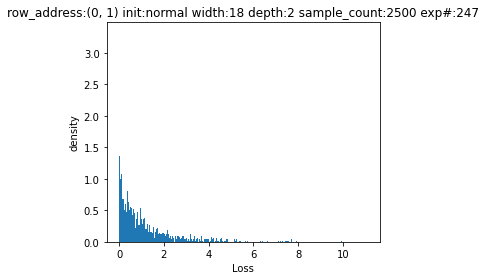


time elapsed:
359.7277808020008


experiment_number:  248
row_address:  (0, 1)
init:  normal
width:  18
depth:  3

min =  -0.0
max =  15.424948692321777
median =  0.6720613539218903
mean =  1.5064669490551608
stdev =  2.203621515166598
mad =  1.4855377346367473



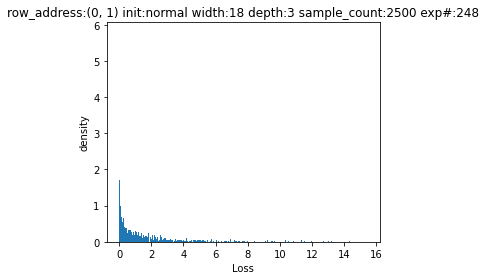


time elapsed:
408.819602182004


experiment_number:  249
row_address:  (0, 1)
init:  normal
width:  18
depth:  4

min =  -0.0
max =  15.424948692321777
median =  0.7424669563770294
mean =  2.1407552565838714
stdev =  3.168299301260033
mad =  2.284850482588373



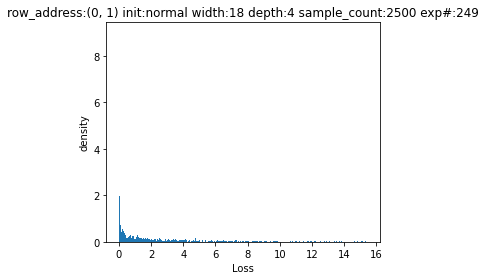


time elapsed:
456.9931346359954


experiment_number:  250
row_address:  (0, 1)
init:  normal
width:  18
depth:  5

min =  -0.0
max =  15.424948692321777
median =  0.6884602308273315
mean =  2.688535969725472
stdev =  4.044817930188978
mad =  3.0187232963820674



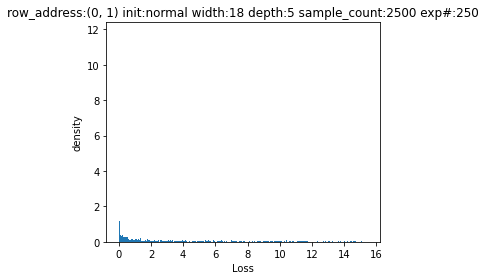


time elapsed:
507.6815469380017


experiment_number:  251
row_address:  (0, 1)
init:  normal
width:  18
depth:  6

min =  -0.0
max =  15.424948692321777
median =  0.6939597427845001
mean =  3.46759282640015
stdev =  4.941311704733117
mad =  3.9578827744944522



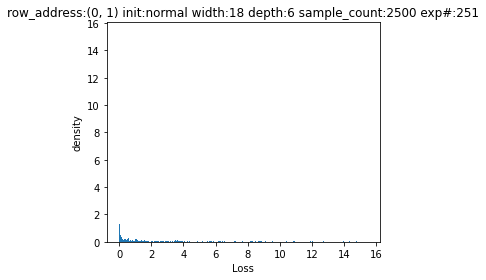


time elapsed:
557.1696851529996


experiment_number:  252
row_address:  (0, 1)
init:  uniform
width:  3
depth:  1

min =  0.01963113434612751
max =  4.367623329162598
median =  0.6931469440460205
mean =  0.7913435045868158
stdev =  0.5009288947317412
mad =  0.3464982945379259



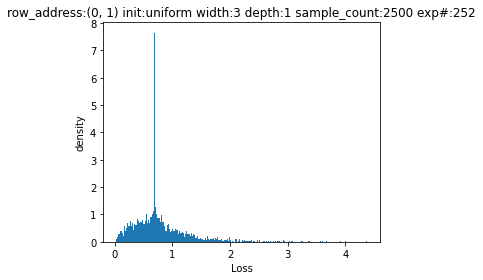


time elapsed:
309.6168715370004


experiment_number:  253
row_address:  (0, 1)
init:  uniform
width:  3
depth:  2

min =  0.030602362006902695
max =  3.5602948665618896
median =  0.6931469440460205
mean =  0.7421163832053542
stdev =  0.3387895651532771
mad =  0.19940731617171384



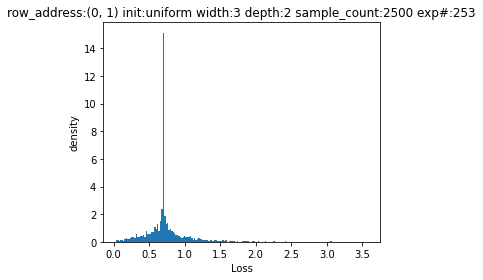


time elapsed:
359.7983314640005


experiment_number:  254
row_address:  (0, 1)
init:  uniform
width:  3
depth:  3

min =  0.009326181374490261
max =  4.671788215637207
median =  0.6931469440460205
mean =  0.7181696606393904
stdev =  0.2712671126031937
mad =  0.124169416742591



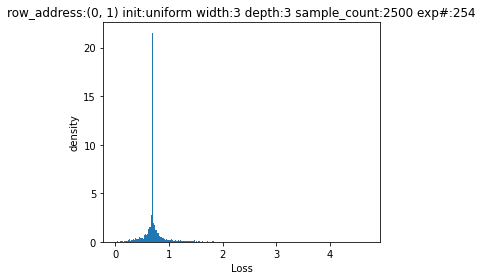


time elapsed:
408.2885881809998


experiment_number:  255
row_address:  (0, 1)
init:  uniform
width:  3
depth:  4

min =  0.014631698839366436
max =  3.5819733142852783
median =  0.6931469440460205
mean =  0.7034939084734768
stdev =  0.1547002284855803
mad =  0.06653984156742546



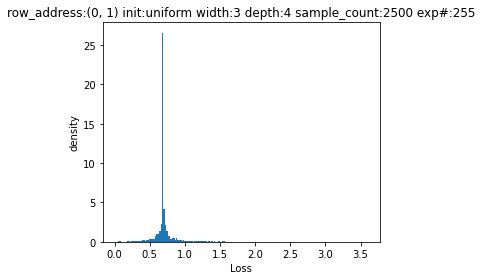


time elapsed:
457.1741652970013


experiment_number:  256
row_address:  (0, 1)
init:  uniform
width:  3
depth:  5

min =  0.1691027134656906
max =  3.0546343326568604
median =  0.6931469440460205
mean =  0.6961509817004203
stdev =  0.11037936376871131
mad =  0.03752709551304909



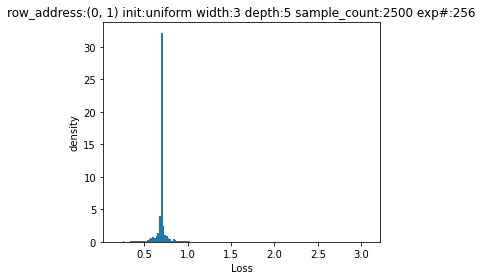


time elapsed:
507.05152310399717


experiment_number:  257
row_address:  (0, 1)
init:  uniform
width:  3
depth:  6

min =  0.12470685690641403
max =  2.0618674755096436
median =  0.6931469440460205
mean =  0.6984357195287942
stdev =  0.08025517552149905
mad =  0.0251508339731652



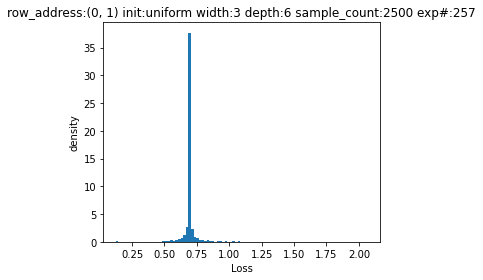


time elapsed:
555.5215247909946


experiment_number:  258
row_address:  (0, 1)
init:  uniform
width:  6
depth:  1

min =  0.0061159213073551655
max =  6.6977314949035645
median =  0.6962477266788483
mean =  0.8782536837717518
stdev =  0.6936672244690086
mad =  0.5110811862248632



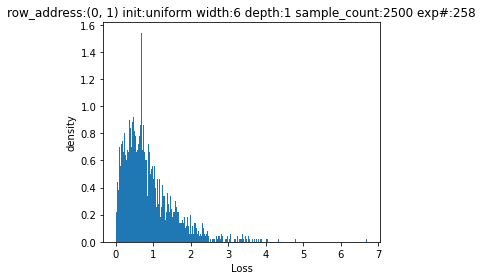


time elapsed:
309.00621708500694


experiment_number:  259
row_address:  (0, 1)
init:  uniform
width:  6
depth:  2

min =  0.0013186681317165494
max =  6.904395580291748
median =  0.6931469440460205
mean =  0.8549065210183151
stdev =  0.7098149917189012
mad =  0.48583667685209436



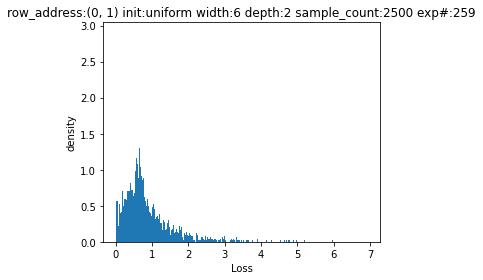


time elapsed:
358.84983003600064


experiment_number:  260
row_address:  (0, 1)
init:  uniform
width:  6
depth:  3

min =  0.0004980612429790199
max =  7.0419602394104
median =  0.6931469440460205
mean =  0.8497675305302022
stdev =  0.7352385529075255
mad =  0.44963813715278295



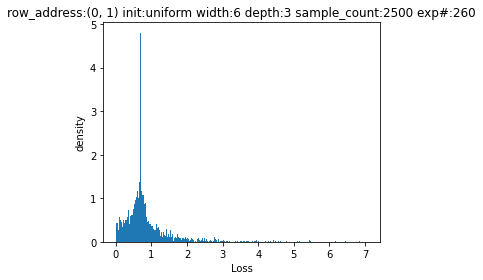


time elapsed:
410.4918065509992


experiment_number:  261
row_address:  (0, 1)
init:  uniform
width:  6
depth:  4

min =  0.0002290272677782923
max =  7.990530490875244
median =  0.6931469440460205
mean =  0.8476132007053239
stdev =  0.7378837370833824
mad =  0.42431800063256914



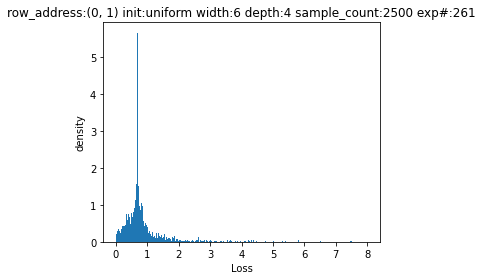


time elapsed:
461.8440279869974


experiment_number:  262
row_address:  (0, 1)
init:  uniform
width:  6
depth:  5

min =  0.0006471581873483956
max =  9.108208656311035
median =  0.6931469440460205
mean =  0.8228353510725311
stdev =  0.7357889462402337
mad =  0.3741396235797175



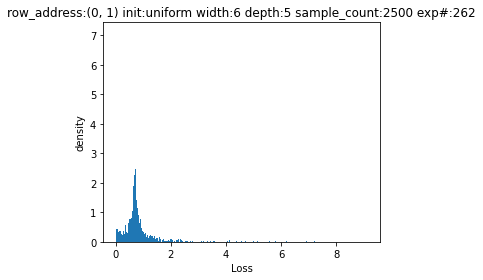


time elapsed:
521.6007703149953


experiment_number:  263
row_address:  (0, 1)
init:  uniform
width:  6
depth:  6

min =  1.657022767176386e-05
max =  11.814332008361816
median =  0.6931469440460205
mean =  0.803932769195937
stdev =  0.7310827091580648
mad =  0.3429869364088663



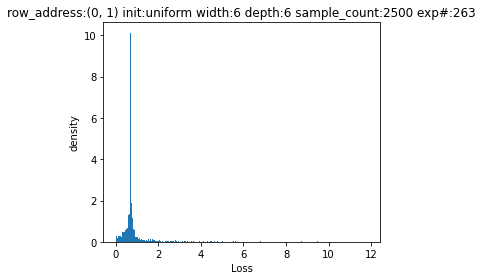


time elapsed:
577.6702021050005


experiment_number:  264
row_address:  (0, 1)
init:  uniform
width:  9
depth:  1

min =  0.0008054638165049255
max =  6.126795291900635
median =  0.6916959881782532
mean =  0.9369058237663237
stdev =  0.8703885387417749
mad =  0.6467845978257414



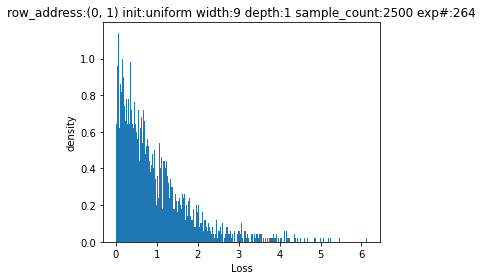


time elapsed:
316.08009673999914


experiment_number:  265
row_address:  (0, 1)
init:  uniform
width:  9
depth:  2

min =  6.437322554120328e-06
max =  8.235957145690918
median =  0.6947328150272369
mean =  1.0524909912137457
stdev =  1.1284801095787815
mad =  0.7930509098862454



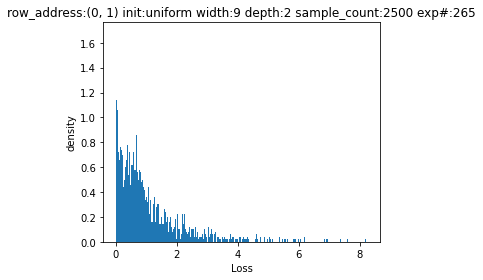


time elapsed:
364.5004538860012


experiment_number:  266
row_address:  (0, 1)
init:  uniform
width:  9
depth:  3

min =  4.768372718899627e-07
max =  15.424948692321777
median =  0.7128141522407532
mean =  1.133939037982354
stdev =  1.356509871046146
mad =  0.9040291656226939



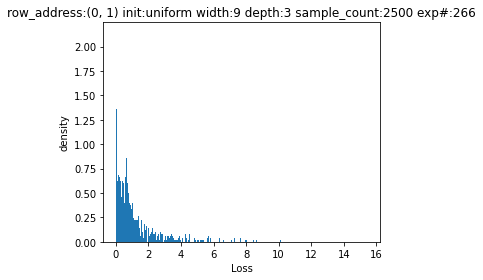


time elapsed:
412.8341318620005


experiment_number:  267
row_address:  (0, 1)
init:  uniform
width:  9
depth:  4

min =  -0.0
max =  15.424948692321777
median =  0.6901716887950897
mean =  1.2664338926883676
stdev =  1.686455911583507
mad =  1.1204888922922582



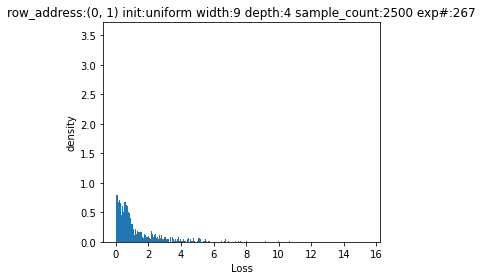


time elapsed:
459.1324216310022


experiment_number:  268
row_address:  (0, 1)
init:  uniform
width:  9
depth:  5

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  1.3791160286429656
stdev =  2.1337170662558163
mad =  1.2923433332181586



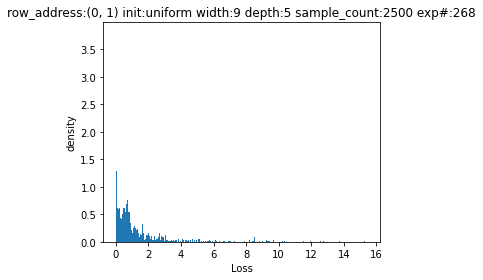


time elapsed:
507.986350332998


experiment_number:  269
row_address:  (0, 1)
init:  uniform
width:  9
depth:  6

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  1.4740808419337825
stdev =  2.33078948327504
mad =  1.4268680995949896



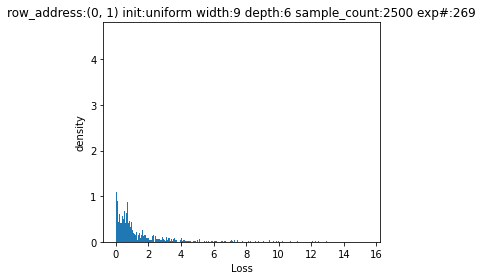


time elapsed:
557.7126685190015


experiment_number:  270
row_address:  (0, 1)
init:  uniform
width:  12
depth:  1

min =  0.0020337505266070366
max =  7.862120151519775
median =  0.6603676974773407
mean =  1.022903281665314
stdev =  1.0404116050148133
mad =  0.7928616961054665



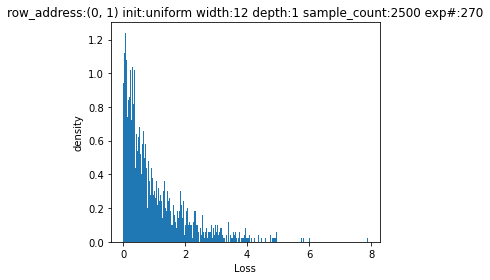


time elapsed:
311.53675741500047


experiment_number:  271
row_address:  (0, 1)
init:  uniform
width:  12
depth:  2

min =  5.579150456469506e-05
max =  13.2791748046875
median =  0.6797294914722443
mean =  1.2187177220171463
stdev =  1.4910576932755675
mad =  1.0719380001257375



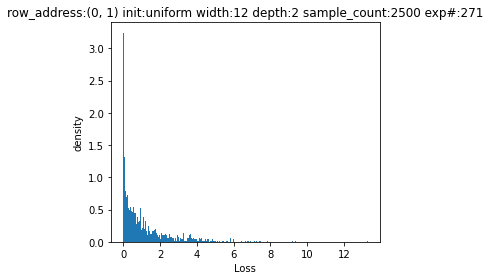


time elapsed:
362.8699076049961


experiment_number:  272
row_address:  (0, 1)
init:  uniform
width:  12
depth:  3

min =  -0.0
max =  15.424948692321777
median =  0.6775835752487183
mean =  1.4769965974942263
stdev =  2.1436826722423166
mad =  1.4425295775994975



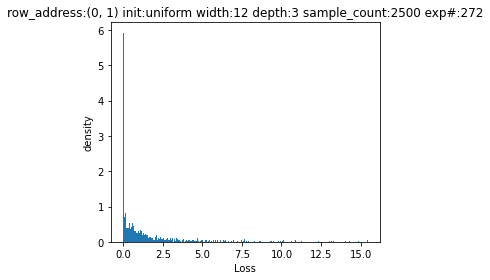


time elapsed:
416.4573439250016


experiment_number:  273
row_address:  (0, 1)
init:  uniform
width:  12
depth:  4

min =  -0.0
max =  15.424948692321777
median =  0.6514328420162201
mean =  1.8501992501041582
stdev =  2.8183856175220647
mad =  1.959344489505579



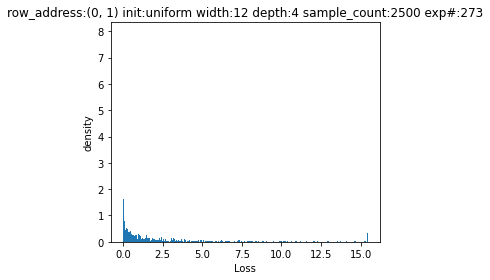


time elapsed:
461.84149030000117


experiment_number:  274
row_address:  (0, 1)
init:  uniform
width:  12
depth:  5

min =  -0.0
max =  15.424948692321777
median =  0.6807291805744171
mean =  2.3589244001244167
stdev =  3.701206320589002
mad =  2.6392286493145076



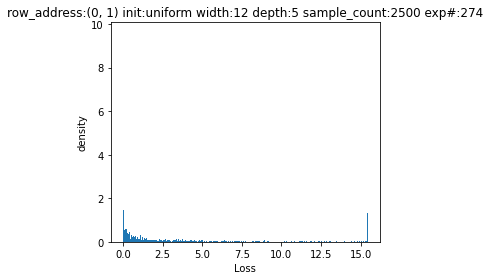


time elapsed:
514.5124439259962


experiment_number:  275
row_address:  (0, 1)
init:  uniform
width:  12
depth:  6

min =  -0.0
max =  15.424948692321777
median =  0.6544683575630188
mean =  2.833207379723525
stdev =  4.348430967320725
mad =  3.2712091408259187



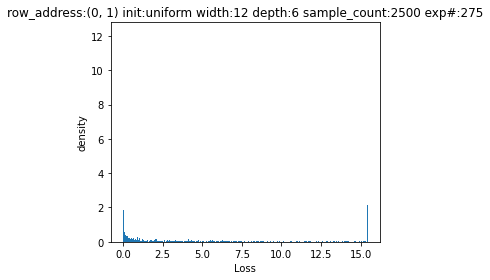


time elapsed:
565.442564129


experiment_number:  276
row_address:  (0, 1)
init:  uniform
width:  15
depth:  1

min =  0.0014906305586919188
max =  8.767210006713867
median =  0.6522989869117737
mean =  1.0536199906047434
stdev =  1.1367294596785937
mad =  0.8643552904285682



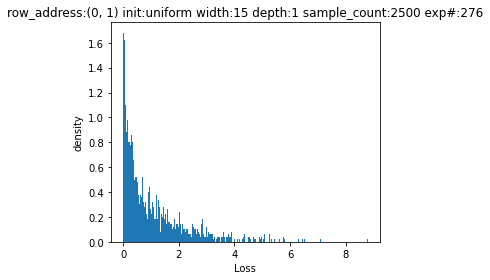


time elapsed:
312.7295655140042


experiment_number:  277
row_address:  (0, 1)
init:  uniform
width:  15
depth:  2

min =  5.960466182841628e-07
max =  15.424948692321777
median =  0.6976167559623718
mean =  1.5067555237413894
stdev =  1.9666632658735979
mad =  1.4449913733360855



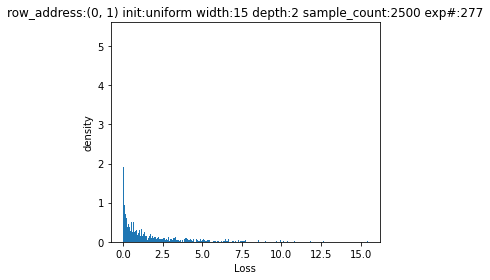


time elapsed:
364.19805146699946


experiment_number:  278
row_address:  (0, 1)
init:  uniform
width:  15
depth:  3

min =  -0.0
max =  15.424948692321777
median =  0.6386407017707825
mean =  2.0274213565087846
stdev =  2.95360919420487
mad =  2.1603503639843398



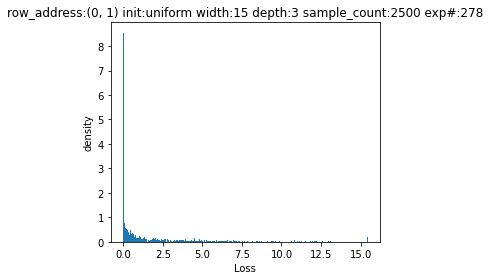


time elapsed:
416.24370925000403


experiment_number:  279
row_address:  (0, 1)
init:  uniform
width:  15
depth:  4

min =  -0.0
max =  15.424948692321777
median =  0.7118040919303894
mean =  2.749166193411598
stdev =  4.018904045040791
mad =  3.0705175663043742



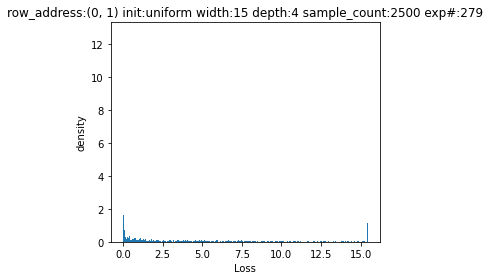


time elapsed:
471.1789784249995


experiment_number:  280
row_address:  (0, 1)
init:  uniform
width:  15
depth:  5

min =  -0.0
max =  15.424948692321777
median =  0.6981818675994873
mean =  3.6135053172736487
stdev =  5.086500848822186
mad =  4.141371928582695



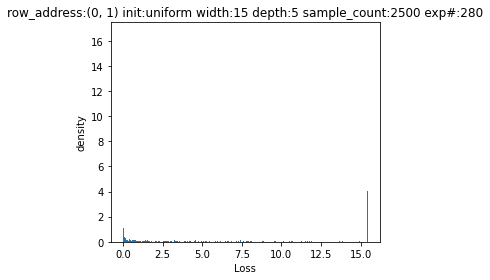


time elapsed:
519.2057937339996


experiment_number:  281
row_address:  (0, 1)
init:  uniform
width:  15
depth:  6

min =  -0.0
max =  15.424948692321777
median =  0.7277818024158478
mean =  4.497608066185874
stdev =  5.893039989175003
mad =  5.098638340735566



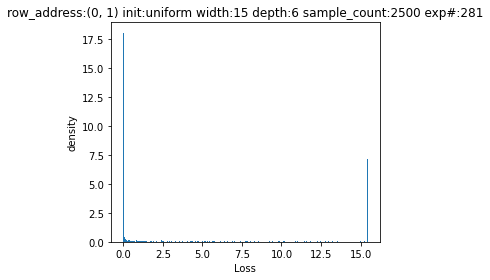


time elapsed:
566.1278522339999


experiment_number:  282
row_address:  (0, 1)
init:  uniform
width:  18
depth:  1

min =  0.00019999357755295932
max =  12.032580375671387
median =  0.7104487121105194
mean =  1.1412316447154969
stdev =  1.2478234457582222
mad =  0.944419863645992



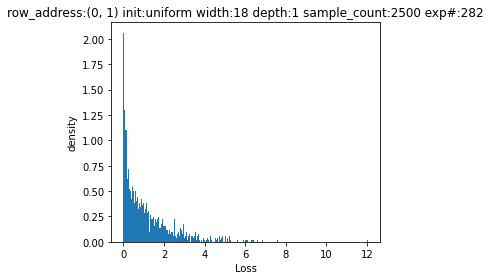


time elapsed:
315.7158113330006


experiment_number:  283
row_address:  (0, 1)
init:  uniform
width:  18
depth:  2

min =  -0.0
max =  15.424948692321777
median =  0.8005399703979492
mean =  1.7883226206481349
stdev =  2.351143803516231
mad =  1.7546948025737903



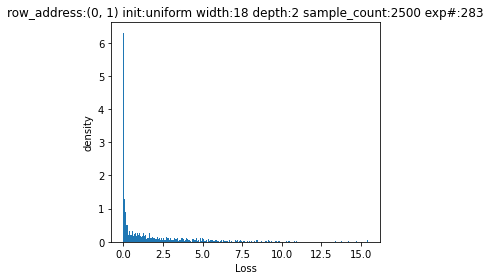


time elapsed:
368.6208179500027


experiment_number:  284
row_address:  (0, 1)
init:  uniform
width:  18
depth:  3

min =  -0.0
max =  15.424948692321777
median =  0.6270986795425415
mean =  2.4913673774057963
stdev =  3.6553316051993106
mad =  2.77402054355104



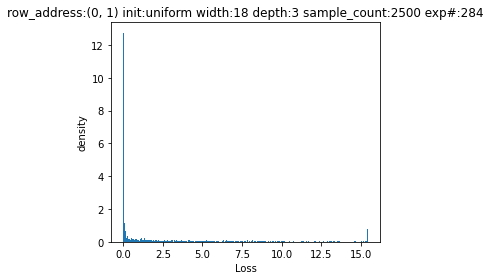


time elapsed:
417.6135502420002


experiment_number:  285
row_address:  (0, 1)
init:  uniform
width:  18
depth:  4

min =  -0.0
max =  15.424948692321777
median =  0.8132069706916809
mean =  3.684933814443642
stdev =  5.022505057105349
mad =  4.111917631269479



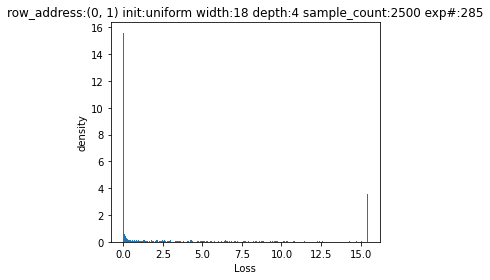


time elapsed:
465.26646719100245


experiment_number:  286
row_address:  (0, 1)
init:  uniform
width:  18
depth:  5

min =  -0.0
max =  15.424948692321777
median =  0.4513448178768158
mean =  4.47778539498466
stdev =  5.947849367928529
mad =  5.1682148730736



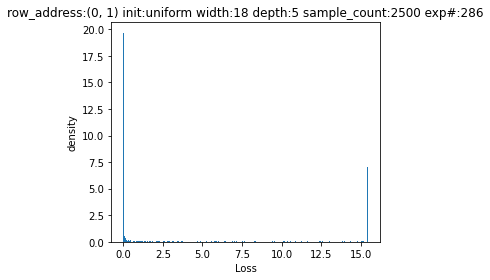


time elapsed:
515.1586800609948


experiment_number:  287
row_address:  (0, 1)
init:  uniform
width:  18
depth:  6

min =  -0.0
max =  15.424948692321777
median =  0.32286861538887024
mean =  5.4118208167256485
stdev =  6.665823815987038
mad =  6.131326497109359



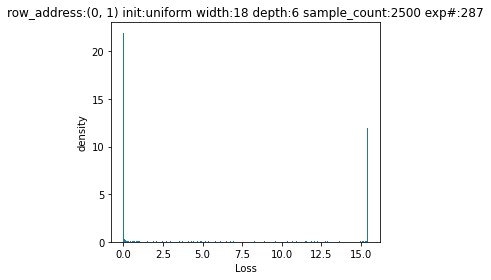


time elapsed:
577.012807168001


experiment_number:  288
row_address:  (1, 2)
init:  HeNormal
width:  3
depth:  1

min =  2.622607780722319e-06
max =  14.790345191955566
median =  0.6931469440460205
mean =  1.2495732130892248
stdev =  1.692285956684309
mad =  1.113288021158407



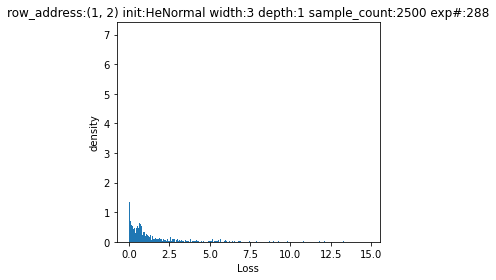


time elapsed:
324.8043737180051


experiment_number:  289
row_address:  (1, 2)
init:  HeNormal
width:  3
depth:  2

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  1.080114503657968
stdev =  1.5151909370972376
mad =  0.8247097440914287



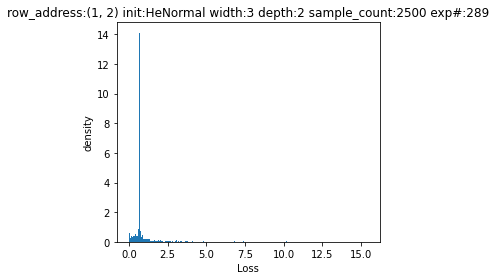


time elapsed:
374.9626485089975


experiment_number:  290
row_address:  (1, 2)
init:  HeNormal
width:  3
depth:  3

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  1.0319028879043013
stdev =  1.5554065064497167
mad =  0.7389184150863856



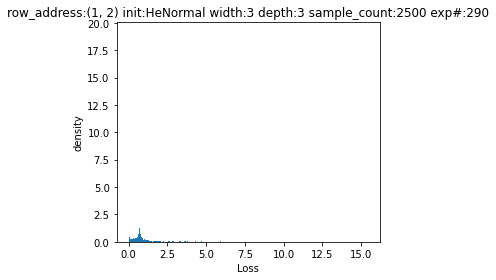


time elapsed:
417.91088904800563


experiment_number:  291
row_address:  (1, 2)
init:  HeNormal
width:  3
depth:  4

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  0.9305306895335396
stdev =  1.327256012918355
mad =  0.556436415262406



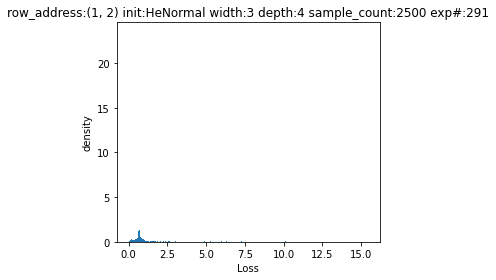


time elapsed:
464.6672428059974


experiment_number:  292
row_address:  (1, 2)
init:  HeNormal
width:  3
depth:  5

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  0.8687600603573843
stdev =  1.2273015872525714
mad =  0.4177335376583259



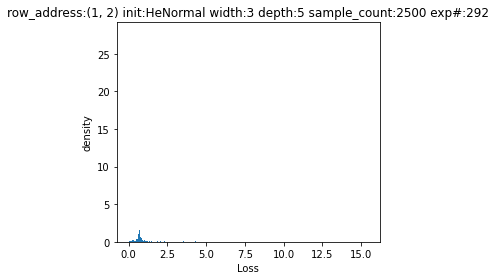


time elapsed:
516.9744969429958


experiment_number:  293
row_address:  (1, 2)
init:  HeNormal
width:  3
depth:  6

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  0.85032247076563
stdev =  1.0913987873502093
mad =  0.3736882931737288



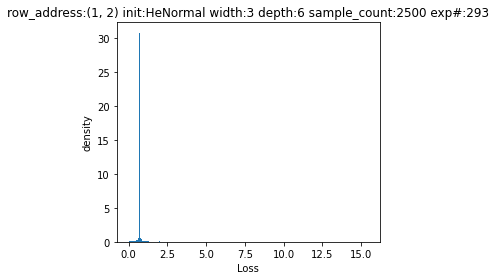


time elapsed:
568.4795322770005


experiment_number:  294
row_address:  (1, 2)
init:  HeNormal
width:  6
depth:  1

min =  1.8358399756834842e-05
max =  12.59761905670166
median =  0.6931469440460205
mean =  1.2342830592750427
stdev =  1.5275320089987967
mad =  1.0863670551332731



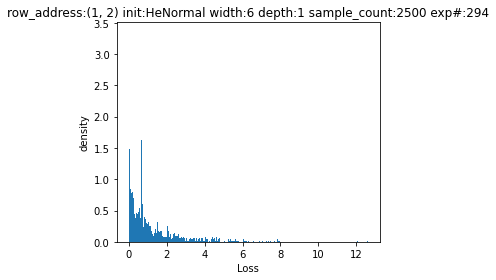


time elapsed:
314.06766356500884


experiment_number:  295
row_address:  (1, 2)
init:  HeNormal
width:  6
depth:  2

min =  9.536747711536009e-07
max =  15.424948692321777
median =  0.6931469440460205
mean =  1.169195051548016
stdev =  1.5153522083128708
mad =  0.9923391115038216



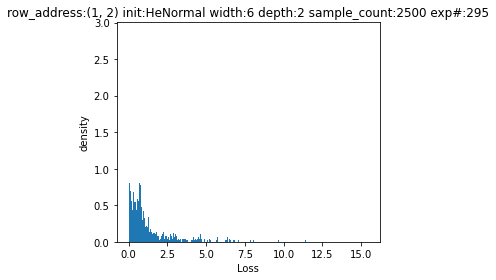


time elapsed:
367.1953019020002


experiment_number:  296
row_address:  (1, 2)
init:  HeNormal
width:  6
depth:  3

min =  3.278260919614695e-06
max =  15.424948692321777
median =  0.6931469440460205
mean =  1.1753035618988281
stdev =  1.6120207360092502
mad =  0.9803180031429174



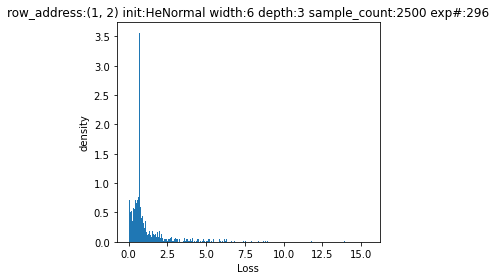


time elapsed:
413.26177274700603


experiment_number:  297
row_address:  (1, 2)
init:  HeNormal
width:  6
depth:  4

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  1.108263332984778
stdev =  1.5487143518869197
mad =  0.8438691280522571



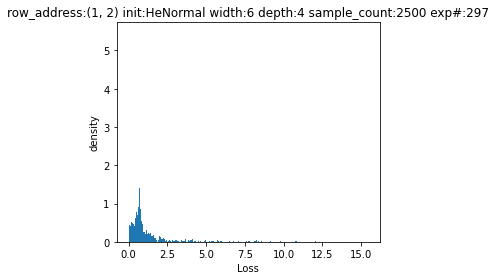


time elapsed:
463.28939833299955


experiment_number:  298
row_address:  (1, 2)
init:  HeNormal
width:  6
depth:  5

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  1.0180352176258989
stdev =  1.421032405583431
mad =  0.7306449930571532



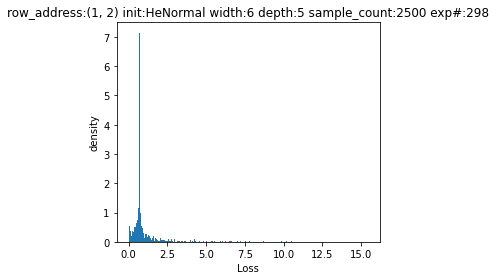


time elapsed:
511.24997348399484


experiment_number:  299
row_address:  (1, 2)
init:  HeNormal
width:  6
depth:  6

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  0.9505212660173235
stdev =  1.3544237277269797
mad =  0.61349297635357



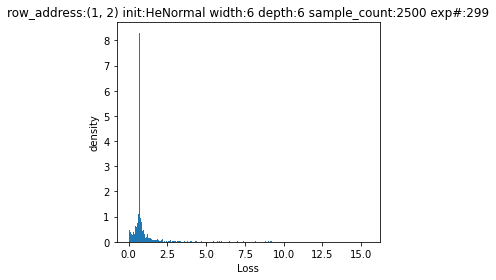


time elapsed:
559.5813127830043


experiment_number:  300
row_address:  (1, 2)
init:  HeNormal
width:  9
depth:  1

min =  1.8716033082455397e-05
max =  10.081997871398926
median =  0.6890046894550323
mean =  1.1855735731278692
stdev =  1.4023208951931143
mad =  1.0372584456225047



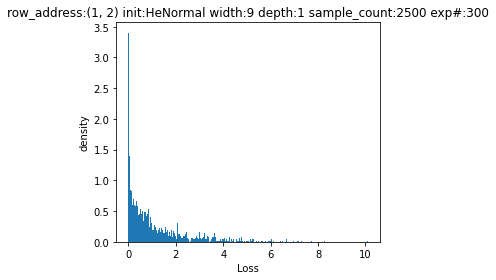


time elapsed:
311.64200144699134


experiment_number:  301
row_address:  (1, 2)
init:  HeNormal
width:  9
depth:  2

min =  2.3841860752327193e-07
max =  12.941367149353027
median =  0.6923086047172546
mean =  1.2346761031269293
stdev =  1.5973731423921051
mad =  1.0799466483122098



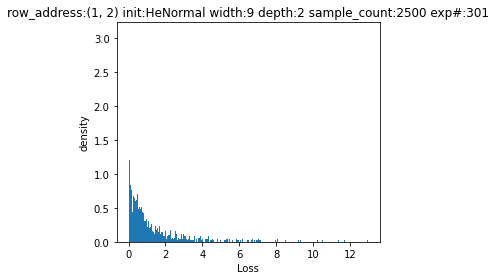


time elapsed:
363.44815059199755


experiment_number:  302
row_address:  (1, 2)
init:  HeNormal
width:  9
depth:  3

min =  -0.0
max =  15.358429908752441
median =  0.6872855424880981
mean =  1.1802494619876005
stdev =  1.581034257895543
mad =  1.0008901336730562



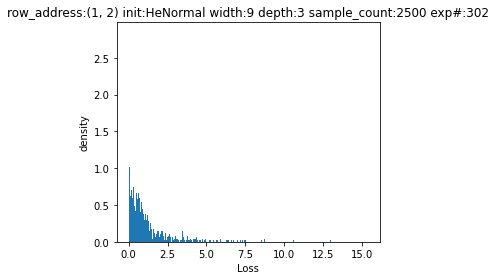


time elapsed:
413.4501868660009


experiment_number:  303
row_address:  (1, 2)
init:  HeNormal
width:  9
depth:  4

min =  -0.0
max =  15.424948692321777
median =  0.6961168944835663
mean =  1.1356208102179668
stdev =  1.5317323471799595
mad =  0.9104624052822357



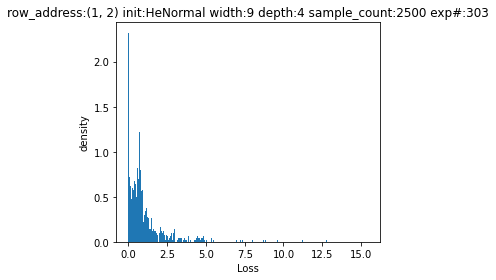


time elapsed:
463.9077283760125


experiment_number:  304
row_address:  (1, 2)
init:  HeNormal
width:  9
depth:  5

min =  -0.0
max =  15.424948692321777
median =  0.6876651346683502
mean =  1.0709346051137023
stdev =  1.5061536758405982
mad =  0.8393507785273879



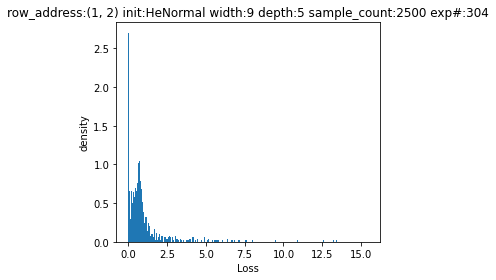


time elapsed:
512.4623028060014


experiment_number:  305
row_address:  (1, 2)
init:  HeNormal
width:  9
depth:  6

min =  -0.0
max =  15.424948692321777
median =  0.6913288533687592
mean =  1.0690677778976703
stdev =  1.5586756323804296
mad =  0.8221443802275268



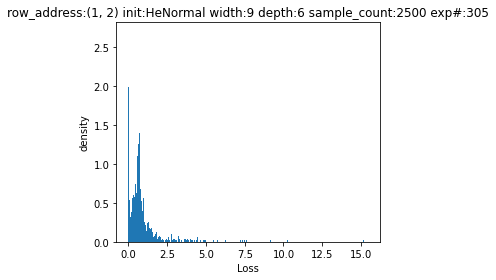


time elapsed:
562.7809642429929


experiment_number:  306
row_address:  (1, 2)
init:  HeNormal
width:  12
depth:  1

min =  6.55653229841846e-06
max =  9.992210388183594
median =  0.668085902929306
mean =  1.2103514257028216
stdev =  1.4400917327488618
mad =  1.0698219804773719



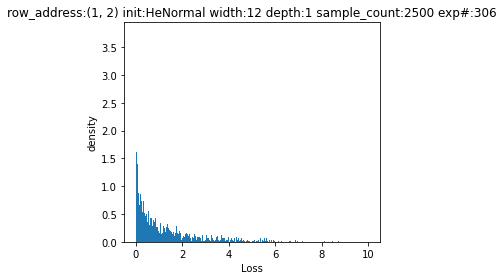


time elapsed:
315.4794496990071


experiment_number:  307
row_address:  (1, 2)
init:  HeNormal
width:  12
depth:  2

min =  5.960466182841628e-07
max =  12.528818130493164
median =  0.6852883398532867
mean =  1.2034627826313502
stdev =  1.4649218985861814
mad =  1.0452771452840153



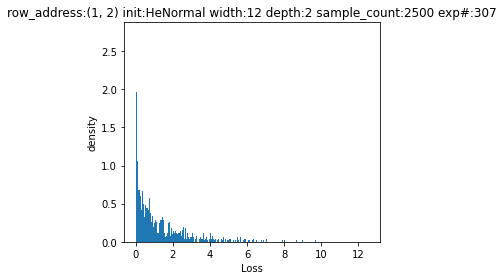


time elapsed:
363.63881613999547


experiment_number:  308
row_address:  (1, 2)
init:  HeNormal
width:  12
depth:  3

min =  2.3841860752327193e-07
max =  15.424948692321777
median =  0.6899940669536591
mean =  1.2416285461726575
stdev =  1.6318721652768347
mad =  1.080054708251179



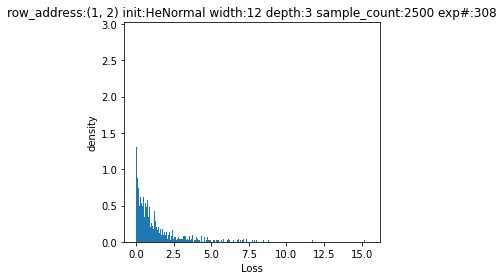


time elapsed:
412.38351335100015


experiment_number:  309
row_address:  (1, 2)
init:  HeNormal
width:  12
depth:  4

min =  -0.0
max =  14.893665313720703
median =  0.6773252487182617
mean =  1.1184202385337452
stdev =  1.4472363587307822
mad =  0.9268631445613547



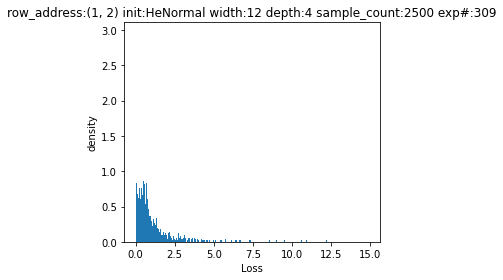


time elapsed:
463.53181881300407


experiment_number:  310
row_address:  (1, 2)
init:  HeNormal
width:  12
depth:  5

min =  -0.0
max =  15.424948692321777
median =  0.6830934286117554
mean =  1.146459851748212
stdev =  1.5780360715303425
mad =  0.9467995853753064



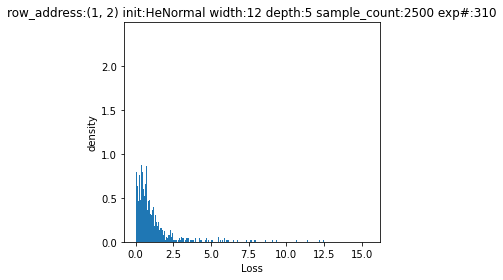


time elapsed:
510.0764490619913


experiment_number:  311
row_address:  (1, 2)
init:  HeNormal
width:  12
depth:  6

min =  -0.0
max =  15.424948692321777
median =  0.6898838877677917
mean =  1.0824555959975812
stdev =  1.460535286947207
mad =  0.8484341539001172



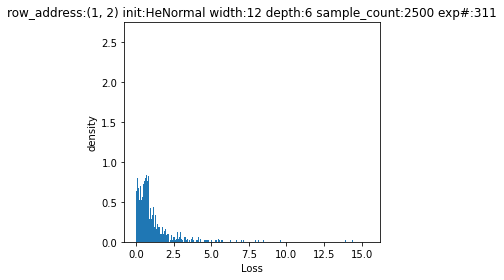


time elapsed:
569.1165977490018


experiment_number:  312
row_address:  (1, 2)
init:  HeNormal
width:  15
depth:  1

min =  2.3842141672503203e-05
max =  10.054046630859375
median =  0.7194264829158783
mean =  1.2755242012605652
stdev =  1.498517056203963
mad =  1.1335469350608818



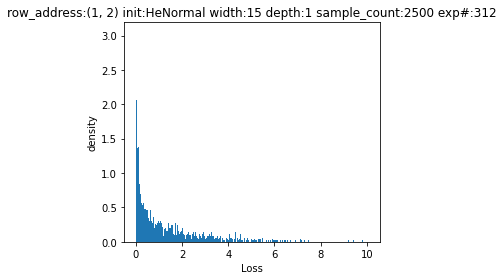


time elapsed:
319.72268571901077


experiment_number:  313
row_address:  (1, 2)
init:  HeNormal
width:  15
depth:  2

min =  5.722062269342132e-06
max =  11.464005470275879
median =  0.7120623886585236
mean =  1.2480719712012294
stdev =  1.4744896053342054
mad =  1.0743861205050143



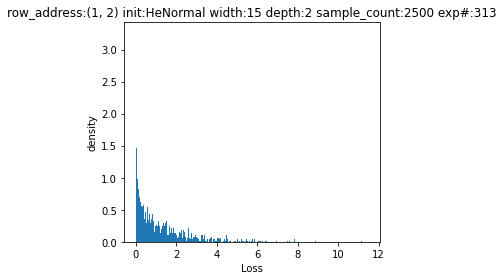


time elapsed:
368.3160324719938


experiment_number:  314
row_address:  (1, 2)
init:  HeNormal
width:  15
depth:  3

min =  1.9073504518019035e-06
max =  10.414678573608398
median =  0.7074583768844604
mean =  1.2342134480051965
stdev =  1.4742054081379161
mad =  1.066159805126968



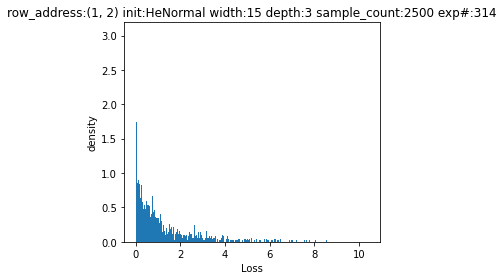


time elapsed:
413.7982854120055


experiment_number:  315
row_address:  (1, 2)
init:  HeNormal
width:  15
depth:  4

min =  -0.0
max =  14.998531341552734
median =  0.7154085636138916
mean =  1.2016402188713036
stdev =  1.526125159359802
mad =  0.9995045870547862



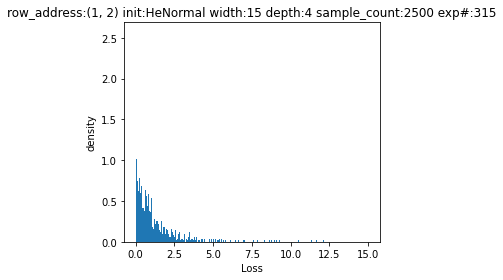


time elapsed:
464.7805254959967


experiment_number:  316
row_address:  (1, 2)
init:  HeNormal
width:  15
depth:  5

min =  -0.0
max =  14.675603866577148
median =  0.704388439655304
mean =  1.1397583725660718
stdev =  1.469574722240152
mad =  0.9372753727717598



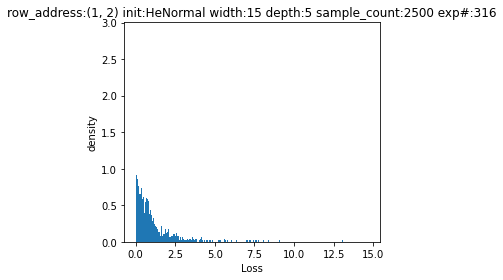


time elapsed:
510.9417444629944


experiment_number:  317
row_address:  (1, 2)
init:  HeNormal
width:  15
depth:  6

min =  -0.0
max =  15.424948692321777
median =  0.6888308823108673
mean =  1.1827246744016395
stdev =  1.589368697808574
mad =  0.9856584167332716



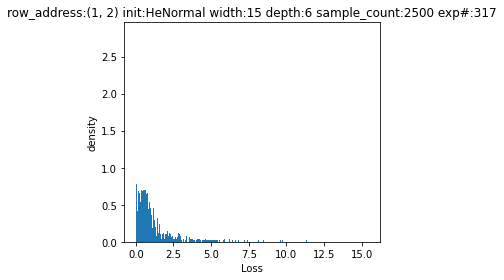


time elapsed:
560.4173544299992


experiment_number:  318
row_address:  (1, 2)
init:  HeNormal
width:  18
depth:  1

min =  1.3232318451628089e-05
max =  8.787115097045898
median =  0.7168071866035461
mean =  1.2816795781208319
stdev =  1.5038137772738343
mad =  1.134123711517744



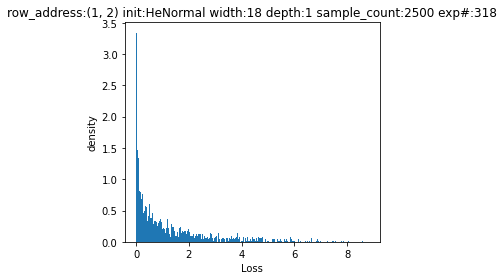


time elapsed:
311.8611265540094


experiment_number:  319
row_address:  (1, 2)
init:  HeNormal
width:  18
depth:  2

min =  3.2067811844171956e-05
max =  11.067499160766602
median =  0.7117397785186768
mean =  1.2696648780949487
stdev =  1.54148090202629
mad =  1.1166980575983194



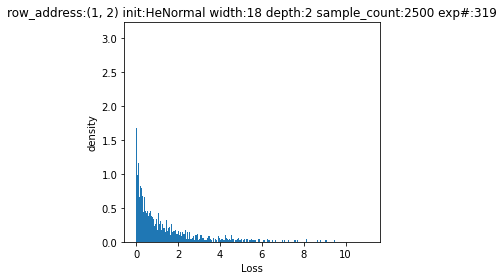


time elapsed:
362.757909715001


experiment_number:  320
row_address:  (1, 2)
init:  HeNormal
width:  18
depth:  3

min =  1.1086525773862377e-05
max =  10.83969497680664
median =  0.7003108561038971
mean =  1.2366600071090081
stdev =  1.5298174998192002
mad =  1.071498222640026



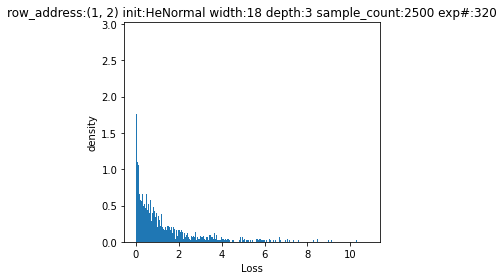


time elapsed:
411.57123373298964


experiment_number:  321
row_address:  (1, 2)
init:  HeNormal
width:  18
depth:  4

min =  4.768372718899627e-07
max =  15.424948692321777
median =  0.725484699010849
mean =  1.270236132651757
stdev =  1.6331388316261455
mad =  1.0779482393956015



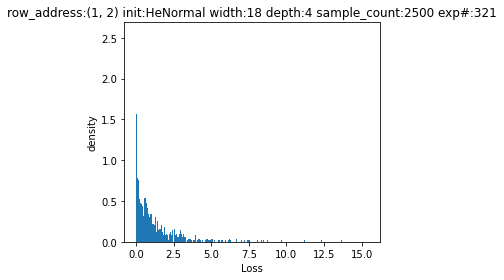


time elapsed:
461.99795852799434


experiment_number:  322
row_address:  (1, 2)
init:  HeNormal
width:  18
depth:  5

min =  -0.0
max =  13.541796684265137
median =  0.6680965721607208
mean =  1.1649459326865574
stdev =  1.4897134738726676
mad =  0.9957085667399334



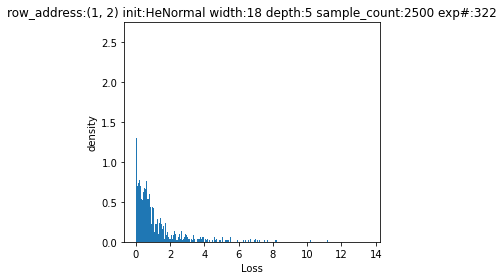


time elapsed:
510.5505790390016


experiment_number:  323
row_address:  (1, 2)
init:  HeNormal
width:  18
depth:  6

min =  -0.0
max =  15.424948692321777
median =  0.6831056177616119
mean =  1.1770424364410481
stdev =  1.562884914682063
mad =  0.9881479312907789



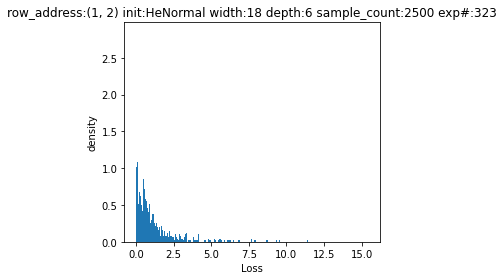


time elapsed:
559.7138056249969


experiment_number:  324
row_address:  (1, 2)
init:  HeUniform
width:  3
depth:  1

min =  1.1324889328534482e-06
max =  13.151727676391602
median =  0.6931469440460205
mean =  1.2115935639340776
stdev =  1.609809764647873
mad =  1.0545400891700105



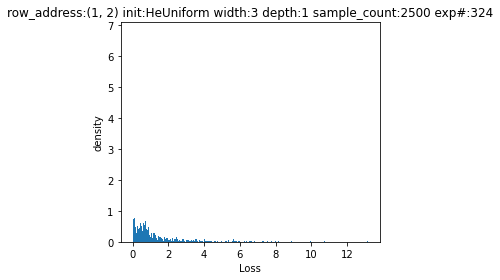


time elapsed:
311.652030769008


experiment_number:  325
row_address:  (1, 2)
init:  HeUniform
width:  3
depth:  2

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  1.0962602029165505
stdev =  1.5768200339991691
mad =  0.8631199374606383



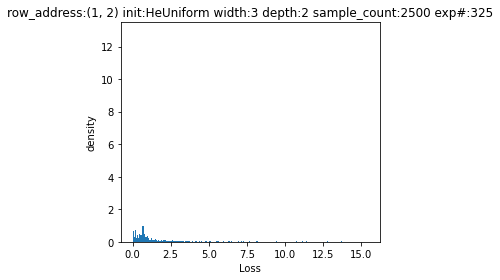


time elapsed:
362.02437777300656


experiment_number:  326
row_address:  (1, 2)
init:  HeUniform
width:  3
depth:  3

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  1.07095735369518
stdev =  1.6567709109480018
mad =  0.8133262791664915



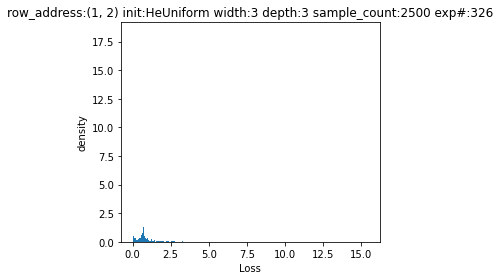


time elapsed:
411.7069863659999


experiment_number:  327
row_address:  (1, 2)
init:  HeUniform
width:  3
depth:  4

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  0.9579287593865985
stdev =  1.4495970715093245
mad =  0.5902050208130927



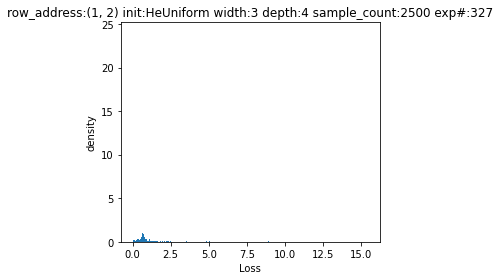


time elapsed:
462.3673471689981


experiment_number:  328
row_address:  (1, 2)
init:  HeUniform
width:  3
depth:  5

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  0.9158580809660951
stdev =  1.3843661615097538
mad =  0.5089585065549092



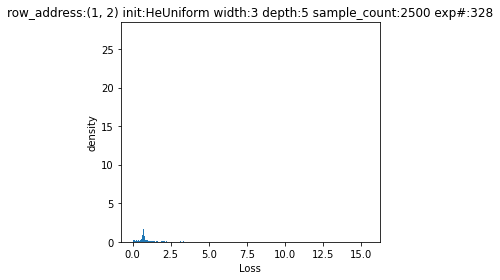


time elapsed:
514.9893136799947


experiment_number:  329
row_address:  (1, 2)
init:  HeUniform
width:  3
depth:  6

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  0.8514428171409895
stdev =  1.093553481736909
mad =  0.37161175392586066



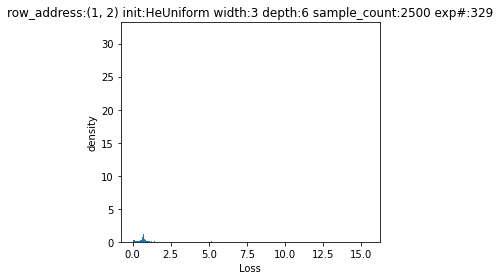


time elapsed:
560.7807243240095


experiment_number:  330
row_address:  (1, 2)
init:  HeUniform
width:  6
depth:  1

min =  7.331398137466749e-06
max =  12.388139724731445
median =  0.6931469440460205
mean =  1.2410438287007453
stdev =  1.5712967000613571
mad =  1.1075799359071128



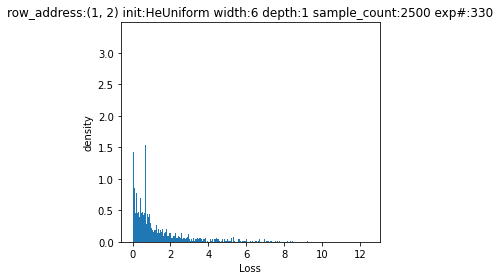


time elapsed:
312.37075475399615


experiment_number:  331
row_address:  (1, 2)
init:  HeUniform
width:  6
depth:  2

min =  1.1920928955078125e-07
max =  14.878077507019043
median =  0.6931469440460205
mean =  1.151754148842073
stdev =  1.4436868162767562
mad =  0.9480258831422479



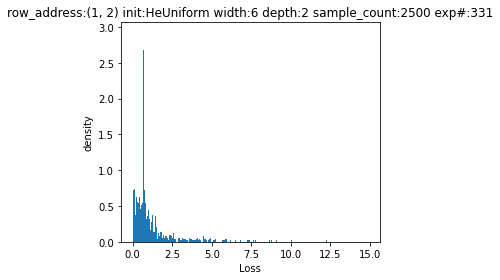


time elapsed:
363.3466180749965


experiment_number:  332
row_address:  (1, 2)
init:  HeUniform
width:  6
depth:  3

min =  5.960464477539063e-08
max =  15.424948692321777
median =  0.6931469440460205
mean =  1.185152123084302
stdev =  1.6643190978550049
mad =  0.9931490621276114



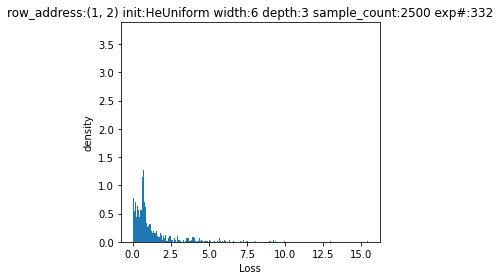


time elapsed:
412.297653763002


experiment_number:  333
row_address:  (1, 2)
init:  HeUniform
width:  6
depth:  4

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  1.0768350765635282
stdev =  1.525578016544443
mad =  0.8460425381654876



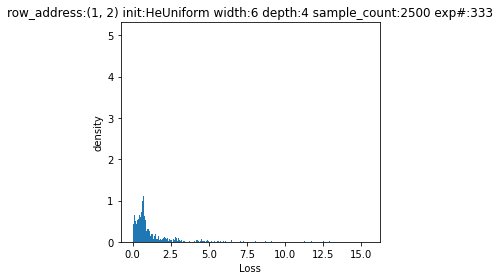


time elapsed:
460.97946914000204


experiment_number:  334
row_address:  (1, 2)
init:  HeUniform
width:  6
depth:  5

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  0.999338524026857
stdev =  1.4254731551715332
mad =  0.7086978865158414



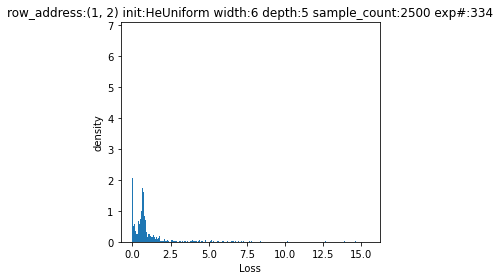


time elapsed:
510.97329937700124


experiment_number:  335
row_address:  (1, 2)
init:  HeUniform
width:  6
depth:  6

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  0.9903913838853438
stdev =  1.3545521124101656
mad =  0.6589216367330534



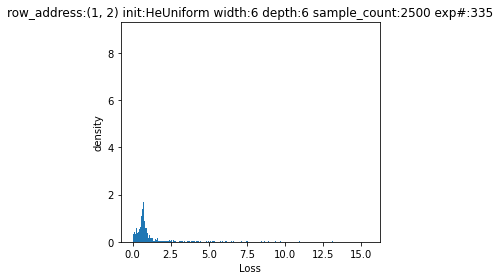


time elapsed:
561.2917605599941


experiment_number:  336
row_address:  (1, 2)
init:  HeUniform
width:  9
depth:  1

min =  9.536747711536009e-07
max =  12.372783660888672
median =  0.7021363079547882
mean =  1.2438541471504412
stdev =  1.472686267865994
mad =  1.0798314450382556



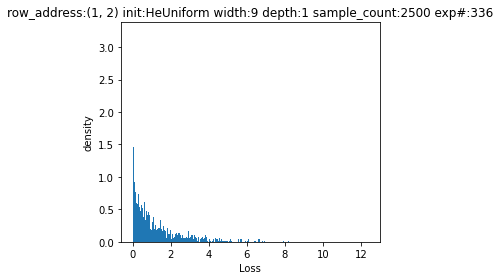


time elapsed:
314.9631969070033


experiment_number:  337
row_address:  (1, 2)
init:  HeUniform
width:  9
depth:  2

min =  3.159051175316563e-06
max =  12.235392570495605
median =  0.7091816961765289
mean =  1.189515954890138
stdev =  1.4172512762435931
mad =  1.00331852197892



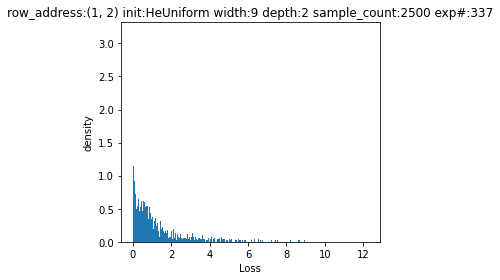


time elapsed:
365.15930064099666


experiment_number:  338
row_address:  (1, 2)
init:  HeUniform
width:  9
depth:  3

min =  1.1920928955078125e-07
max =  14.399890899658203
median =  0.6846419274806976
mean =  1.1550037974864722
stdev =  1.5593498008740536
mad =  0.9797633179807376



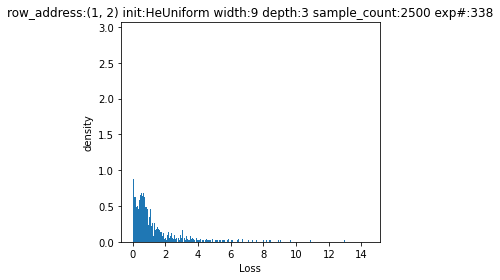


time elapsed:
415.7394982500118


experiment_number:  339
row_address:  (1, 2)
init:  HeUniform
width:  9
depth:  4

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  1.123796480484649
stdev =  1.4602867382534206
mad =  0.8981541456903371



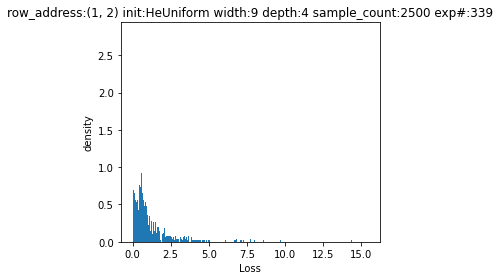


time elapsed:
463.59369753699866


experiment_number:  340
row_address:  (1, 2)
init:  HeUniform
width:  9
depth:  5

min =  -0.0
max =  15.424948692321777
median =  0.6912617981433868
mean =  1.0790068595479192
stdev =  1.5239369785185757
mad =  0.84896576374469



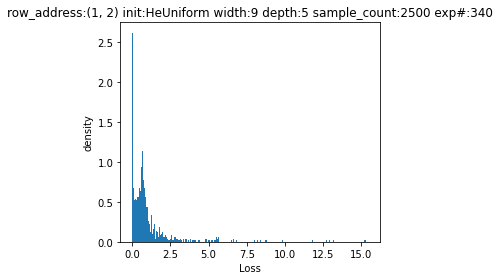


time elapsed:
509.8463060619979


experiment_number:  341
row_address:  (1, 2)
init:  HeUniform
width:  9
depth:  6

min =  -0.0
max =  15.424948692321777
median =  0.6931469440460205
mean =  1.1021688090990545
stdev =  1.5858868153219976
mad =  0.8690010513774132



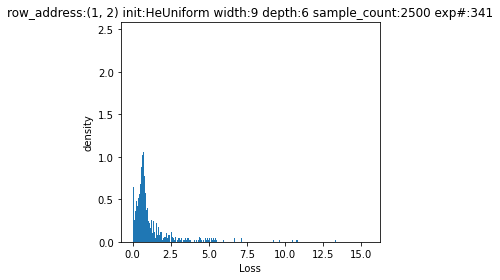


time elapsed:
561.06079692801


experiment_number:  342
row_address:  (1, 2)
init:  HeUniform
width:  12
depth:  1



In [ ]:

#these are the scenarios we'll cycle through,
#each combination will be one experiment
#as configured init_params don't accept lists
scenarios = \
{'width' : [3,6,9,12,15,18],
'depth' : [1,2,3,4,5,6],
'init' : ['HeNormal', 'HeUniform', 'normal', 'uniform'],
'init_param1' : -1,
'init_param2' : 1,
'init_param3' : 0.5,
'row_address' : [(0,50),(0,1),(1,2),(2,3),(3,4),(4,5),(5,6),(6,7),(7,8)],
}

#row address refers to rows inspected. e.g. (0,50) is for train_am[0:50], (0,1) for train_am[0:1]
#this notebook only looks at target index in row_address list, 
#e.g. target_row_address_index = {1,2} looks at (0,1),(1,2)

# target_row_address_index = {0}
target_row_address_index = {1,2}
# target_row_address_index = {3,4}
# target_row_address_index = {5,6}
# target_row_address_index = {7,8}

#sample_count is the number of samples collected in each histogram
#in another notebook we based this on time span instead of quantity
sample_count = 2500

experiment_log = {}
experiment_number = 0
max_experiment_number = 0

#we'll store the collected samples serving as basis for histogram in this dataframe
#which we'll download at conclusion of notebook, one column per histogram
#the first 13 rows store collected statistics for the experiment
experiment_df = pd.DataFrame(index = ['chart_title', 'experiment_number', 'row_address', 'init', 'width', 'depth', 'sample_count', 'min', 'max', 'median', 'mean', 'stdev', 'mad'] + list(range(sample_count)))


for row_address in scenarios['row_address']:
    
  # print()
  # print("____________________________________")
  # print("************************************")
  # print()
  # print("row_address scenario = ", row_address)
  # print()
  
  train = tf.convert_to_tensor(train_am[row_address[0]:row_address[1]])
  # labels = tf.convert_to_tensor(labels)
  labels = labels_am[row_address[0]:row_address[1]].to_numpy()

  for init in scenarios['init']:

    # print()
    # print("____________________________________")
    # print("************************************")
    # print()
    # print("init scenario = ", init)
    # print()

    for width in scenarios['width']:

      for depth in scenarios['depth']:

        #we'll run different notebooks for different row_address scenarios
        if scenarios['row_address'].index(row_address) in target_row_address_index:

          print()
          print("experiment_number: ", experiment_number)
          print("row_address: ", row_address)
          print("init: ", init)
          print("width: ", width)
          print("depth: ", depth)
          print()
          
          #chart_title is the string at top of each histogram detailing configuration
          chart_title = 'row_address:' + str(row_address) + ' init:' + str(init) \
                        + ' width:'+str(width) + ' depth:'+str(depth) \
                        + ' sample_count:' + str(sample_count) \
                        + ' exp#:'+str(experiment_number)
          
          start_time = timeit.default_timer()
          
          #we'll aggregate sampled loss values in a unique list for each setup
          loss_list = []
          
          #here is where we collect samples
          for i in range(sample_count):
            
            #initialize model (the sampled weights are conducted with initialization)
            model = create_model(width, 
                                depth, 
                                init=init, 
                                init_param1=scenarios['init_param1'], 
                                init_param2=scenarios['init_param2'],
                                init_param3=scenarios['init_param3'])
            
            #run inference without training
            predictions = model.predict(train)
            
            #calucate binary cross entropy and append to list
            cce = tf.keras.losses.BinaryCrossentropy(from_logits=False)
            loss = cce(labels, predictions).numpy()
            loss_list.append(loss)
          
          #now store those experiment results in the dataframe
          stats_df = pd.DataFrame({'loss_list':loss_list})
          experiment_df[experiment_number] = [chart_title, experiment_number, row_address, init, width, depth, sample_count, 
                                              stats_df['loss_list'].min(),
                                              stats_df['loss_list'].max(),
                                              stats_df['loss_list'].median(),
                                              stats_df['loss_list'].mean(),
                                              stats_df['loss_list'].std(),
                                              stats_df['loss_list'].mad(),
                                              ] + loss_list
            
          # stats_df = pd.DataFrame({'loss_list':loss_list})
          print("min = ", stats_df['loss_list'].min())
          print("max = ", stats_df['loss_list'].max())
          print("median = ", stats_df['loss_list'].median())
          print("mean = ", stats_df['loss_list'].mean())
          # print("mode = ", stats_df['loss_list'].mode())
          print("stdev = ", stats_df['loss_list'].std())
          print("mad = ", stats_df['loss_list'].mad())
          print()
          
          #now we'll display the histogram in printouts for this cell
          fig, axs = plt.subplots(1, sharey=False, tight_layout=True)
        
          n, bins, patches = \
          axs.hist(np.array(loss_list), bins=np.arange(np.array(loss_list).min(), np.array(loss_list).max() + 0.02, 0.02), density=True)

          # axs.plot(bins)
          axs.set_xlabel('Loss')
          axs.set_ylabel('density')
          axs.set_title(chart_title)
          
          filename = chart_title + '_122221' + '.png'
          
          #I think this save operation doesn't work in colab, so just download the dataframe below
          # plt.savefig(filename, bbox_inches='tight')

          plt.show()
          
          print()
          print("time elapsed:")
          print(timeit.default_timer() - start_time)
          print()
          
          max_experiment_number = experiment_number

        experiment_number += 1

print("complete")

In [ ]:
#the first 13 rows are the statistics for each scenario
experiment_df[:14]

In [ ]:
#this cell downloads the log of samples from colaboratory

experiment_download_name = '_exp_' + str(max_experiment_number) + '_123021' + '_colab_row_addres_' + str(row_address) + '.csv'

experiment_df.to_csv(experiment_download_name, index=False)

from google.colab import files

files.download(experiment_download_name)


In [ ]:
#voila

In [9]:
#this is an alternate configuration that collects samples
#based on sampling time instead of number of samples
#this is useful when trying to max out colab running window
#e.g. can collect one configuration over 23.5 hours
#by using: 
#while (timeit.default_timer() - start_time) < (24*60*60 - 30*60):

In [ ]:


# #initialize model
# scenarios = \
# {'width' : [18], #[3,6,9,12,15,18],
# 'depth' : [3], #[1,2,3,4,5,6],
# 'init' : ['HeNormal'], #['HeNormal', 'HeUniform', 'normal', 'uniform'],
# 'init_param1' : -1,
# 'init_param2' : 1,
# 'init_param3' : 0.5,
# 'row_address' : [(0,1)], #[(0,50),(0,1),(1,2),(2,3),(3,4),(4,5),(5,6),(6,7),(7,8)],
# }

# target_row_address_index = {0}
# # target_row_address_index = {1,2}
# # target_row_address_index = {3,4}
# # target_row_address_index = {5,6}
# # target_row_address_index = {7,8}

# sample_count = '24hr'

# experiment_log = {}
# experiment_number = 68
# max_experiment_number = 0

# index_list = ['chart_title', 'experiment_number', 'row_address', 'init', 'width', 'depth', 'sample_count', 'min', 'max', 'median', 'mean', 'stdev', 'mad']
# experiment_df = pd.DataFrame(index = index_list)

# for row_address in scenarios['row_address']:
    
#   # print()
#   # print("____________________________________")
#   # print("************************************")
#   # print()
#   # print("row_address scenario = ", row_address)
#   # print()
  
#   train = tf.convert_to_tensor(train_am[row_address[0]:row_address[1]])
#   # labels = tf.convert_to_tensor(labels)
#   labels = labels_am[row_address[0]:row_address[1]].to_numpy()

#   for init in scenarios['init']:

#     # print()
#     # print("____________________________________")
#     # print("************************************")
#     # print()
#     # print("init scenario = ", init)
#     # print()

#     for width in scenarios['width']:

#       for depth in scenarios['depth']:

#         #we'll run different notebooks for different row_address scenarios
#         if scenarios['row_address'].index(row_address) in target_row_address_index:

#           print()
#           print("experiment_number: ", experiment_number)
#           print("row_address: ", row_address)
#           print("init: ", init)
#           print("width: ", width)
#           print("depth: ", depth)
#           print()
          
#           chart_title = 'row_address:' + str(row_address) + ' init:' + str(init) \
#                         + ' width:'+str(width) + ' depth:'+str(depth) \
#                         + ' sample_count:' + str(sample_count) \
#                         + ' exp#:'+str(experiment_number)
          
#           start_time = timeit.default_timer()
        
#           loss_list = []
#           # for i in range(sample_count):
#           i = -1
#           while (timeit.default_timer() - start_time) < (24*60*60 - 30*60):
#             i+= 1

#             model = create_model(width, 
#                                 depth, 
#                                 init=init, 
#                                 init_param1=scenarios['init_param1'], 
#                                 init_param2=scenarios['init_param2'],
#                                 init_param3=scenarios['init_param3'])
            
#             predictions = model.predict(train)
#             cce = tf.keras.losses.BinaryCrossentropy(from_logits=False)
#             loss = cce(labels, predictions).numpy()
#             loss_list.append(loss)

#           stats_df = pd.DataFrame({'loss_list':loss_list})
#           experiment_df2 = pd.DataFrame({experiment_number : [chart_title, experiment_number, row_address, init, width, depth, sample_count, 
#                                               stats_df['loss_list'].min(),
#                                               stats_df['loss_list'].max(),
#                                               stats_df['loss_list'].median(),
#                                               stats_df['loss_list'].mean(),
#                                               stats_df['loss_list'].std(),
#                                               stats_df['loss_list'].mad(),
#                                               ] + loss_list}, index = index_list + list(range(len(loss_list))))

#           experiment_df = pd.concat([experiment_df, experiment_df2], axis=1)
            
#           # stats_df = pd.DataFrame({'loss_list':loss_list})
#           print("min = ", stats_df['loss_list'].min())
#           print("max = ", stats_df['loss_list'].max())
#           print("median = ", stats_df['loss_list'].median())
#           print("mean = ", stats_df['loss_list'].mean())
#           # print("mode = ", stats_df['loss_list'].mode())
#           print("stdev = ", stats_df['loss_list'].std())
#           print("mad = ", stats_df['loss_list'].mad())
#           print()
          
#           fig, axs = plt.subplots(1, sharey=False, tight_layout=True)
        
#           n, bins, patches = \
#           axs.hist(np.array(loss_list), bins=np.arange(np.array(loss_list).min(), np.array(loss_list).max() + 0.02, 0.02), density=True)

#           # axs.plot(bins)
#           axs.set_xlabel('Loss')
#           axs.set_ylabel('density')
#           axs.set_title(chart_title)
          
#           filename = chart_title + '_010822_Fig3_scale' + '.png'

#           # plt.savefig(filename, bbox_inches='tight')

#           plt.show()
          
#           print()
#           print("time elapsed:")
#           print(timeit.default_timer() - start_time)
#           print()
          
#           max_experiment_number = experiment_number

#         experiment_number += 1

# print("complete")